## 1. Import Libraries

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, TimeSeriesSplit
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_percentage_error, mean_absolute_error, mean_squared_error, r2_score

import warnings
from scipy.signal import savgol_filter
warnings.filterwarnings("ignore")

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (12, 5)
plt.rcParams["axes.grid"] = True

!pip install yfinance -q
import yfinance as yf

print("Semua library berhasil di-import.")

Semua library berhasil di-import.


## 2. Data Understanding

### 2.1 Load Dataset

In [ ]:
df = pd.read_csv("/content/Data_Historis_ANTM.csv")
df["Tanggal"] = pd.to_datetime(df["Tanggal"], dayfirst=True)
df = df.sort_values("Tanggal").reset_index(drop=True)

n_before_dedup = len(df)
dup_mask = df.duplicated(subset="Tanggal", keep=False)
if dup_mask.any():
    dup_rows = df.loc[dup_mask].copy()
    # +2 karena: +1 untuk index 0-based -> baris ke-1, +1 lagi untuk baris header CSV
    dup_rows["Baris_di_CSV"] = dup_rows.index + 2
    print(f"[PERINGATAN] Ditemukan {dup_mask.sum()} baris dengan tanggal duplikat "
          f"pada Data_Historis_ANTM.csv:")
    print(dup_rows[["Baris_di_CSV", "Tanggal", "Terakhir", "Pembukaan", "Tertinggi", "Terendah"]].to_string(index=False))
    print("Baris duplikat di atas akan dibuang (menyisakan kemunculan PERTAMA saja untuk "
          "tiap tanggal), karena index tanggal yang tidak unik dapat menyebabkan error "
          "saat reindexing pada perhitungan Directional Accuracy maupun validasi silang "
          "time-series.")
    print(">> Silakan cek langsung baris-baris di atas pada file Data_Historis_ANTM.csv "
          "Anda (nomor baris sudah termasuk baris header) untuk memastikan mana yang "
          "seharusnya dihapus atau diperbaiki tanggalnya.")

df = df.drop_duplicates(subset="Tanggal", keep="first")
n_after_dedup = len(df)

df = df.set_index("Tanggal")

df = df.rename(columns={
    "Terakhir"   : "Close",
    "Pembukaan"  : "Open",
    "Tertinggi"  : "High",
    "Terendah"   : "Low",
    "Vol."       : "Volume",
    "Perubahan%" : "Perubahan%"
})

def normalize_price(price):
    if price > 10000.0:
        return price / 1000.0
    return price

for col in ["Close", "Open", "High", "Low"]:
    df[col] = df[col].apply(lambda x: normalize_price(x * 1000))

def convert_volume(vol_str):
    if isinstance(vol_str, str):
        vol_str = vol_str.replace(",", ".")
        if "M" in vol_str:
            return float(vol_str.replace("M", "")) * 1_000_000
        elif "K" in vol_str:
            return float(vol_str.replace("K", "")) * 1_000
        elif "B" in vol_str:
            return float(vol_str.replace("B", "")) * 1_000_000_000
    return vol_str

df["Volume"] = df["Volume"].apply(convert_volume)

start_date = str(df.index.min().date())
end_date   = str(df.index.max().date())
print(f"Rentang data ANTM: {start_date} s.d. {end_date}")

print("\nMengunduh data emas (GC=F)...")
gold = yf.download("GC=F", start=start_date, end=end_date, progress=False)
if isinstance(gold.columns, pd.MultiIndex):
    gold.columns = ["_".join(c).strip() for c in gold.columns]
    close_col = [c for c in gold.columns if "Close" in c][0]
else:
    close_col = "Close"
gold = gold[[close_col]].rename(columns={close_col: "Gold_Close"})
gold.index = pd.to_datetime(gold.index)
print(f"  Data emas: {len(gold)} baris, NaN: {gold['Gold_Close'].isna().sum()}")
gold["Gold_Close_Normalized"] = gold["Gold_Close"] / 100

print("\nMengunduh data nikel (LME Nickel Futures, NI=F)...")
nickel_ok = False

try:
    nickel_raw = yf.download("NI=F", start=start_date, end=end_date, progress=False)
    if isinstance(nickel_raw.columns, pd.MultiIndex):
        nickel_raw.columns = ["_".join(c).strip() for c in nickel_raw.columns]
        cc = [c for c in nickel_raw.columns if "Close" in c][0]
    else:
        cc = "Close"
    nickel_raw = nickel_raw[[cc]].rename(columns={cc: "Nickel_Close_Raw"})
    nan_pct = nickel_raw["Nickel_Close_Raw"].isna().mean()
    if len(nickel_raw) > 100 and nan_pct < 0.5:
        nickel = nickel_raw.copy()
        nickel_ok = True
        print(f"  [OK] NI=F: {len(nickel)} baris, NaN: {nan_pct:.1%}")
        print(f"  Range harga nikel dunia: {nickel['Nickel_Close_Raw'].min():.0f} - {nickel['Nickel_Close_Raw'].max():.0f} USD/ton")
    else:
        print(f"  [GAGAL] NI=F: {len(nickel_raw)} baris / NaN {nan_pct:.1%} (data tidak memadai)")
except Exception as e:
    print(f"  [GAGAL] NI=F: {e}")

# PENTING: Nickel_Close harus berupa harga komoditas nikel dunia, BUKAN
# harga saham perusahaan tambang seperti INCO.JK (Vale Indonesia). Memakai
# harga saham sebagai proksi "harga nikel" secara konseptual tidak valid,
# karena harga saham juga dipengaruhi faktor lain (kinerja perusahaan,
# sentimen investor, dsb.) di luar harga komoditas itu sendiri. Oleh karena
# itu, TIDAK ada fallback ke saham perusahaan tambang ataupun estimasi
# sintetis di sini. Jika NI=F gagal diunduh, satu-satunya jalur pengganti
# yang sah adalah data harga nikel dunia asli yang diunggah manual.
if not nickel_ok:
    print()
    print("=" * 65)
    print("  DATA NIKEL DUNIA (NI=F) TIDAK DAPAT DIUNDUH OTOMATIS")
    print("  Download data HARGA NIKEL DUNIA (bukan saham perusahaan tambang)")
    print("  dari salah satu sumber berikut:")
    print("  >> https://www.macrotrends.net/1423/nickel-prices-historical-chart-data")
    print("  >> https://www.investing.com/commodities/nickel-historical-data")
    print("  >> https://www.lme.com/en/Metals/Non-ferrous/LME-Nickel")
    print("  Rename file menjadi 'nickel_data.csv', lalu upload ke /content/")
    print("=" * 65)
    try:
        nickel_manual = pd.read_csv("/content/nickel_data.csv")
        print(f"  Kolom terbaca dari nickel_data.csv: {nickel_manual.columns.tolist()}")

        date_candidates = [c for c in nickel_manual.columns
                            if any(k in c.lower() for k in ["date", "tanggal"])]
        price_candidates = [c for c in nickel_manual.columns
                             if any(k in c.lower() for k in ["price", "close", "terakhir", "value", "harga"])]
        if not date_candidates:
            raise ValueError(f"Tidak ditemukan kolom tanggal di antara: {nickel_manual.columns.tolist()}")
        if not price_candidates:
            raise ValueError(f"Tidak ditemukan kolom harga di antara: {nickel_manual.columns.tolist()}")

        date_col = date_candidates[0]
        price_col = price_candidates[0]
        print(f"  Kolom tanggal terdeteksi : '{date_col}'")
        print(f"  Kolom harga terdeteksi   : '{price_col}'")
        print(f"  Contoh nilai mentah harga: {nickel_manual[price_col].head(3).tolist()}")

        def parse_price_string(series):
            """Parser angka yang tahan terhadap dua format penulisan:
            - Format AS/Internasional : 16,050.00  (koma=ribuan, titik=desimal)
            - Format Indonesia/Eropa  : 16.050,00  (titik=ribuan, koma=desimal)
            Tanpa penanganan ini, angka format Indonesia (umum pada
            investing.com versi ID) akan salah diparse dan menghasilkan NaN
            untuk SELURUH baris, karena '16.050,00' -> hapus koma saja ->
            '16.050.00' (dua titik sekaligus, tidak valid sebagai float)."""
            s = series.astype(str).str.strip()
            def _parse_one(v):
                if v in ("", "nan", "None"):
                    return np.nan
                has_comma, has_dot = "," in v, "." in v
                if has_comma and has_dot:
                    if v.rfind(",") > v.rfind("."):
                        v = v.replace(".", "").replace(",", ".")   # format ID/EU
                    else:
                        v = v.replace(",", "")                     # format AS
                elif has_comma and not has_dot:
                    parts = v.split(",")
                    v = v.replace(",", "") if (len(parts) > 1 and len(parts[-1]) == 3) else v.replace(",", ".")
                elif has_dot and not has_comma:
                    parts = v.split(".")
                    if len(parts) > 1 and len(parts[-1]) == 3:
                        v = v.replace(".", "")
                return v
            return pd.to_numeric(s.apply(_parse_one), errors="coerce")

        # dayfirst=True karena investing.com versi ID umumnya format tanggal DD/MM/YYYY
        nickel_manual[date_col] = pd.to_datetime(nickel_manual[date_col], dayfirst=True, errors="coerce")
        nickel_manual = nickel_manual.set_index(date_col)[[price_col]].rename(columns={price_col: "Nickel_Close_Raw"})
        nickel_manual["Nickel_Close_Raw"] = parse_price_string(nickel_manual["Nickel_Close_Raw"])

        n_before = len(nickel_manual)
        nickel_manual = nickel_manual.dropna()
        print(f"  Baris terbaca: {n_before}, baris valid setelah parsing: {len(nickel_manual)}")
        if len(nickel_manual) == 0:
            raise ValueError("Semua baris gagal diparse (tanggal dan/atau harga tidak terbaca). Periksa format file nickel_data.csv.")

        overlap = nickel_manual.index.intersection(df.index)
        file_span_days = (nickel_manual.index.max() - nickel_manual.index.min()).days + 1
        antm_span_days = (df.index.max() - df.index.min()).days + 1
        print(f"  Rentang tanggal file nikel : {nickel_manual.index.min().date()} s.d. {nickel_manual.index.max().date()}  ({file_span_days} hari, {len(nickel_manual)} baris)")
        print(f"  Rentang tanggal data ANTM  : {df.index.min().date()} s.d. {df.index.max().date()}  ({antm_span_days} hari)")
        print(f"  Jumlah tanggal beririsan dengan data ANTM: {len(overlap)}")

        if len(overlap) == 0:
            raise ValueError(
                "Rentang tanggal file nikel TIDAK beririsan sama sekali dengan data ANTM.\n"
                f"  -> File nickel_data.csv hanya berisi {file_span_days} hari data "
                f"({nickel_manual.index.min().date()} s.d. {nickel_manual.index.max().date()}),\n"
                f"     padahal data ANTM butuh rentang {antm_span_days} hari "
                f"({df.index.min().date()} s.d. {df.index.max().date()}).\n"
                "  -> Ini biasanya terjadi karena saat mengunduh dari investing.com, "
                "rentang tanggal masih default (mis. '1 bulan' atau 'terkini'), bukan "
                "rentang tanggal historis penuh.\n"
                "  -> PERBAIKAN: buka https://www.investing.com/commodities/nickel-historical-data, "
                "gunakan date-range picker untuk mengatur Start Date = "
                f"{df.index.min().strftime('%m/%d/%Y')} dan End Date = "
                f"{df.index.max().strftime('%m/%d/%Y')}, klik Apply, baru unduh "
                "ulang datanya sebagai nickel_data.csv."
            )
        elif len(overlap) < 0.5 * antm_span_days:
            print(f"  [PERINGATAN] Hanya {len(overlap)} dari {antm_span_days} hari yang beririsan "
                  f"({len(overlap)/antm_span_days:.1%}). Sebagian besar tanggal ANTM tidak akan "
                  "memiliki data nikel asli dan akan diisi lewat forward/backward-fill, yang bisa "
                  "melemahkan kualitas fitur ini. Disarankan mengunduh rentang tanggal nikel yang "
                  "lebih lengkap dari investing.com sebelum melanjutkan.")

        nickel = nickel_manual.sort_index()
        nickel_ok = True
        print(f"  [OK] File manual: {len(nickel)} baris valid")
    except FileNotFoundError:
        raise RuntimeError(
            "Data harga nikel dunia (NI=F) gagal diunduh dan file "
            "'/content/nickel_data.csv' tidak ditemukan. Notebook DIHENTIKAN "
            "di sini secara sengaja, agar model tidak dilatih memakai proksi "
            "yang tidak valid secara konseptual (mis. harga saham perusahaan "
            "tambang). Silakan unggah data harga nikel dunia asli lalu jalankan "
            "ulang sel ini."
        )
    except Exception as e:
        raise RuntimeError(f"Gagal membaca file nickel_data.csv: {e}")

nickel_mean = nickel["Nickel_Close_Raw"].mean()
if nickel_mean > 10000:
    print(f"  Data nikel dalam skala besar ({nickel_mean:.0f}), melakukan normalisasi...")
    nickel["Nickel_Close"] = nickel["Nickel_Close_Raw"] / 10
    print(f"  Range setelah normalisasi: {nickel['Nickel_Close'].min():.0f} - {nickel['Nickel_Close'].max():.0f}")
else:
    print(f"  Data nikel dalam skala wajar ({nickel_mean:.0f})")
    nickel["Nickel_Close"] = nickel["Nickel_Close_Raw"]

nickel.index = pd.to_datetime(nickel.index)
print("\nMengunduh data nilai tukar USD/IDR...")
try:
    usdidr = yf.download("IDR=X", start=start_date, end=end_date, progress=False)
    if isinstance(usdidr.columns, pd.MultiIndex):
        usdidr.columns = ["_".join(c).strip() for c in usdidr.columns]
        usdidr_col = [c for c in usdidr.columns if "Close" in c][0]
    else:
        usdidr_col = "Close"
    usdidr = usdidr[[usdidr_col]].rename(columns={usdidr_col: "USDIDR_Close"})
    usdidr.index = pd.to_datetime(usdidr.index)
    print(f"  [OK] IDR=X: {len(usdidr)} baris, NaN: {usdidr['USDIDR_Close'].isna().sum()}")
except Exception as e:
    print(f"  [GAGAL] IDR=X: {e}")
    print("  Menggunakan nilai tukar konstan sebagai fallback (15800 IDR/USD).")
    usdidr = pd.DataFrame({"USDIDR_Close": 15800.0}, index=df.index)

df = df.join(gold[["Gold_Close"]], how="left")
df = df.join(nickel[["Nickel_Close"]], how="left")
df["Gold_Close"] = df["Gold_Close"].ffill().bfill()
df["Nickel_Close"] = df["Nickel_Close"].ffill().bfill()
df = df.join(usdidr[["USDIDR_Close"]], how="left")
df["USDIDR_Close"] = df["USDIDR_Close"].ffill().bfill()

print(f"\nRingkasan akhir:")
print(f"  NaN Gold_Close   : {df['Gold_Close'].isna().sum()}")
print(f"  NaN Nickel_Close : {df['Nickel_Close'].isna().sum()}")
print(f"  NaN USDIDR_Close : {df['USDIDR_Close'].isna().sum()}")
print(f"  Kolom dataset    : {df.columns.tolist()}")
print(f"\nStatistik harga nikel setelah normalisasi:")
print(f"  Min: {df['Nickel_Close'].min():.2f}")
print(f"  Max: {df['Nickel_Close'].max():.2f}")
print(f"  Mean: {df['Nickel_Close'].mean():.2f}")
print(f"  Std: {df['Nickel_Close'].std():.2f}")
df.head()

Rentang data ANTM: 2012-03-02 s.d. 2026-02-27

Mengunduh data emas (GC=F)...
  Data emas: 3516 baris, NaN: 0

Mengunduh data nikel (LME Nickel Futures, NI=F)...


ERROR:yfinance:HTTP Error 404: {"quoteSummary":{"result":null,"error":{"code":"Not Found","description":"Quote not found for symbol: NI=F"}}}
ERROR:yfinance:
1 Failed download:
ERROR:yfinance:['NI=F']: YFTzMissingError('possibly delisted; no timezone found')


  [GAGAL] NI=F: 0 baris / NaN nan% (data tidak memadai)

  DATA NIKEL DUNIA (NI=F) TIDAK DAPAT DIUNDUH OTOMATIS
  Download data HARGA NIKEL DUNIA (bukan saham perusahaan tambang)
  dari salah satu sumber berikut:
  >> https://www.macrotrends.net/1423/nickel-prices-historical-chart-data
  >> https://www.investing.com/commodities/nickel-historical-data
  >> https://www.lme.com/en/Metals/Non-ferrous/LME-Nickel
  Rename file menjadi 'nickel_data.csv', lalu upload ke /content/
  Kolom terbaca dari nickel_data.csv: ['Date', 'Price', 'Open', 'High', 'Low', 'Vol.', 'Change %']
  Kolom tanggal terdeteksi : 'Date'
  Kolom harga terdeteksi   : 'Price'
  Contoh nilai mentah harga: ['17,678.50', '17,720.75', '18,050.75']
  Baris terbaca: 3436, baris valid setelah parsing: 3436
  Rentang tanggal file nikel : 2012-03-01 s.d. 2026-02-27  (5112 hari, 3436 baris)
  Rentang tanggal data ANTM  : 2012-03-02 s.d. 2026-02-27  (5111 hari)
  Jumlah tanggal beririsan dengan data ANTM: 3232
  [OK] File manual: 3

,Close,Open,High,Low,Volume,Perubahan%,Gold_Close,Nickel_Close,USDIDR_Close
2012-03-02,1940.0,1930.0,1950.0,1930.0,5070000.0,"0,52%",1708.800049,1940.1,9055.0
2012-03-05,1930.0,1930.0,1940.0,1920.0,2110000.0,"-0,52%",1703.000000,1899.5,9055.0
2012-03-06,1900.0,1920.0,1920.0,1880.0,8000000.0,"-1,55%",1671.400024,1866.6,9113.0
2012-03-07,1850.0,1880.0,1880.0,1840.0,15340000.0,"-2,63%",1683.300049,1882.0,9115.0
2012-03-08,1870.0,1850.0,1870.0,1850.0,5400000.0,"1,08%",1698.099976,1871.7,9085.0


### 2.2 Last Rows

In [ ]:
df.tail()

,Close,Open,High,Low,Volume,Perubahan%,Gold_Close,Nickel_Close,USDIDR_Close
2026-02-23,4390.0,4320.0,4440.0,4290.0,154320000.0,"4,03%",5204.700195,1724.663,16843.400391
2026-02-24,4380.0,4440.0,4550.0,4370.0,166390000.0,"-0,23%",5155.799805,1797.413,16804.300781
2026-02-25,4460.0,4400.0,4500.0,4340.0,103580000.0,"1,83%",5206.399902,1805.075,16816.800781
2026-02-26,4330.0,4470.0,4480.0,4270.0,99950000.0,"-2,91%",5176.500000,1772.075,16749.800781
2026-02-27,4350.0,4330.0,4370.0,4230.0,80410000.0,"0,46%",5176.500000,1767.850,16749.800781


In [ ]:
!pip install dataframe_image -q
import dataframe_image as dfi
import matplotlib.pyplot as plt

# Asumsi nama variabel dataframe Anda adalah 'df'
# Mengambil 5 baris data seperti contoh di gambar
df_tabel = df.head(5)

plt.rc('font', size=14)          # Ukuran font default untuk semua teks
plt.rc('axes', titlesize=18)     # Ukuran font untuk judul axes
plt.rc('axes', labelsize=16)     # Ukuran font untuk x dan y labels
plt.rc('xtick', labelsize=14)    # Ukuran font untuk tick x
plt.rc('ytick', labelsize=14)    # Ukuran font untuk tick y

# Menyimpan dataframe menjadi gambar beresolusi tinggi menggunakan matplotlib
fig, ax = plt.subplots(figsize=(20, 4))  # Adjust figsize as needed
ax.axis('off') # Hide axes
ax.table(cellText=df_tabel.values, colLabels=df_tabel.columns, rowLabels=df_tabel.index, loc='center')

# Adjust layout to prevent labels from being cut off
plt.tight_layout()

plt.savefig('tabel_saham_antm_HD.png', dpi=300)
plt.close(fig) # Close the figure to avoid displaying it in the output

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.7/6.7 MB 58.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 180.6/180.6 kB 18.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 47.7/47.7 MB 14.8 MB/s eta 0:00:00


### 2.3 Dataset Information

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 3390 entries, 2012-03-02 to 2026-02-27
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Close         3390 non-null   float64
 1   Open          3390 non-null   float64
 2   High          3390 non-null   float64
 3   Low           3390 non-null   float64
 4   Volume        3390 non-null   float64
 5   Perubahan%    3390 non-null   object 
 6   Gold_Close    3390 non-null   float64
 7   Nickel_Close  3390 non-null   float64
 8   USDIDR_Close  3390 non-null   float64
dtypes: float64(8), object(1)
memory usage: 264.8+ KB


### 2.4 Statistical Summary

In [ ]:
df.describe()

,Close,Open,High,Low,Volume,Gold_Close,Nickel_Close,USDIDR_Close
count,3390.000000,3390.000000,3390.000000,3390.000000,3.390000e+03,3390.000000,3390.000000,3390.000000
mean,1363.266372,1366.294395,1390.599705,1341.541003,9.503287e+07,1733.376281,1580.425618,13731.547900
std,769.690632,770.735763,787.470163,753.192819,1.537749e+08,695.071774,510.274587,1928.044975
min,287.000000,290.000000,294.000000,285.000000,1.120000e+06,1050.800049,759.000000,8995.200195
25%,790.000000,795.000000,805.000000,780.000000,2.337000e+07,1273.400024,1268.000000,13105.000000
50%,1113.500000,1122.500000,1140.000000,1091.000000,5.177000e+07,1575.149963,1536.250000,14099.365723
75%,1835.000000,1840.000000,1868.750000,1813.750000,1.058050e+08,1877.074951,1786.800000,14970.300293
max,4760.000000,4760.000000,4970.000000,4550.000000,2.190000e+09,5318.399902,6171.440000,17051.900391


### 2.5 Missing Value Check

In [ ]:
print("Jumlah missing values per kolom:")
print(df.isnull().sum())

Jumlah missing values per kolom:
Close           0
Open            0
High            0
Low             0
Volume          0
Perubahan%      0
Gold_Close      0
Nickel_Close    0
USDIDR_Close    0
dtype: int64


### 2.6 Close Price Movement (Full Period)

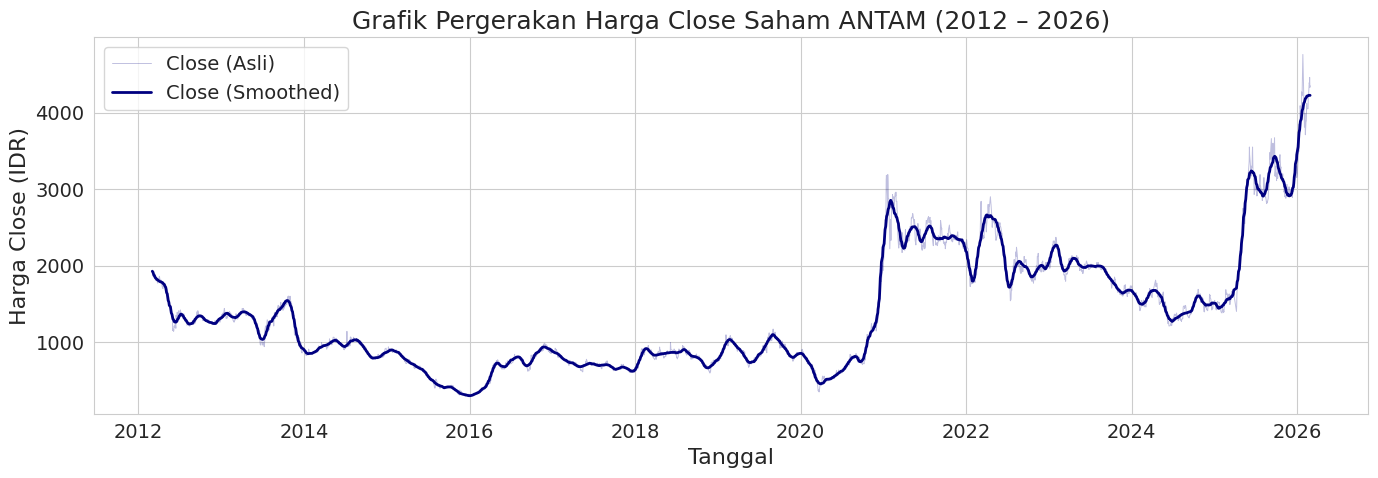

In [ ]:
plt.figure(figsize=(14, 5))
plt.plot(df.index, df["Close"], color="navy", alpha=0.25, linewidth=0.7, label="Close (Asli)")

n_c = len(df["Close"])
wl_c = 51 if n_c >= 51 else (n_c if n_c % 2 == 1 else n_c - 1)
close_s = savgol_filter(df["Close"].values, window_length=wl_c, polyorder=3)
plt.plot(df.index, close_s, color="navy", linewidth=2, label="Close (Smoothed)")

plt.title("Grafik Pergerakan Harga Close Saham ANTAM (2012 – 2026)")
plt.xlabel("Tanggal")
plt.ylabel("Harga Close (IDR)")
plt.legend()
plt.tight_layout()
plt.show()


### 2.7 Trading Volume

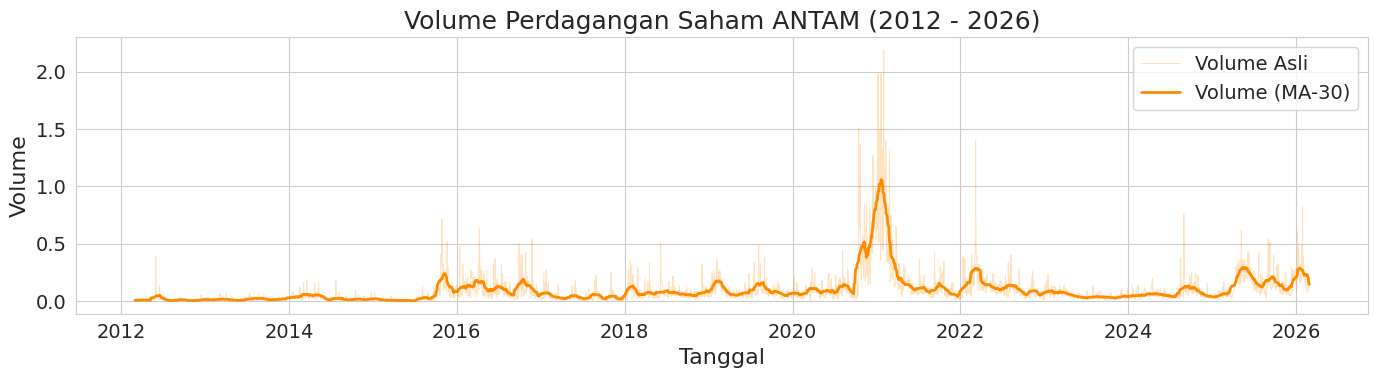

In [ ]:
plt.figure(figsize=(14,4))
plt.plot(df.index, df["Volume"], color="darkorange", alpha=0.25, linewidth=0.7, label="Volume Asli")
vol_smooth = df["Volume"].rolling(window=30, center=True, min_periods=1).mean()
plt.plot(df.index, vol_smooth, color="darkorange", linewidth=2, label="Volume (MA-30)")
plt.title("Volume Perdagangan Saham ANTAM (2012 - 2026)")
plt.xlabel("Tanggal")
plt.ylabel("Volume")
import matplotlib.ticker as ticker
plt.gca().yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f"{x/1e9:.1f}"))
plt.legend()
plt.tight_layout()
plt.show()


### 2.8 Candlestick Chart (Last 12 Months)

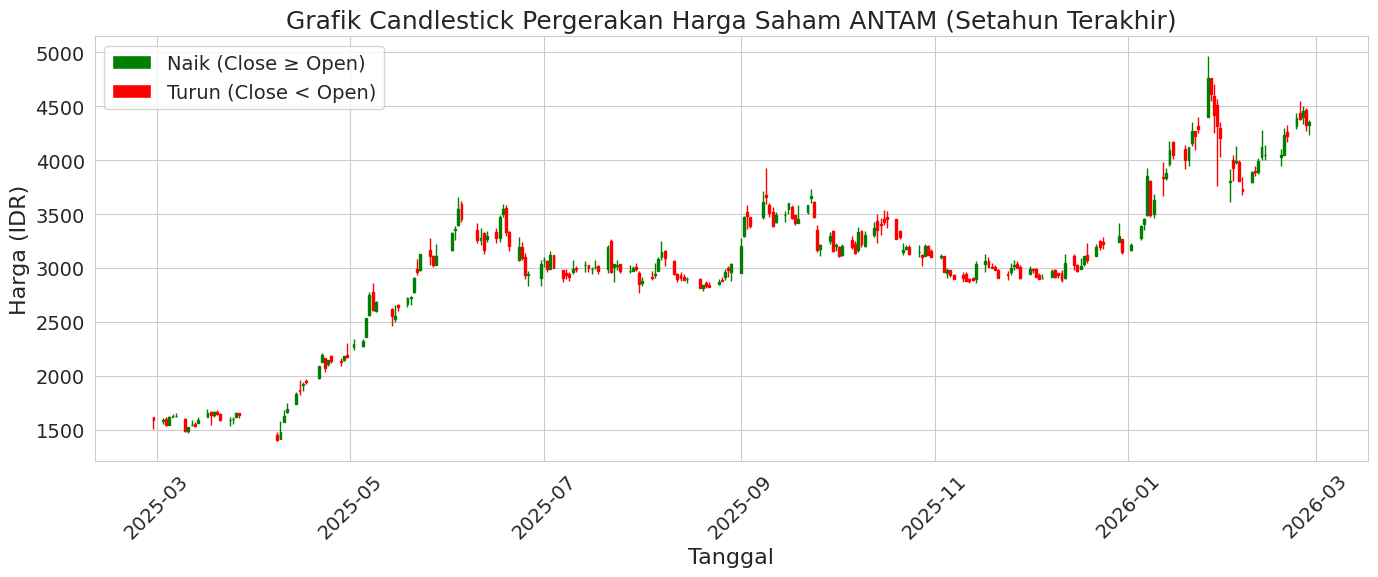

In [ ]:
last_year = df.last("365D").copy()

fig, ax = plt.subplots(figsize=(14, 6))
width = 0.6
for date, row in last_year.iterrows():
    color = "green" if row["Close"] >= row["Open"] else "red"
    ax.vlines(date, row["Low"], row["High"], color=color, linewidth=1)
    body_low  = min(row["Open"], row["Close"])
    body_high = max(row["Open"], row["Close"])
    ax.add_patch(plt.Rectangle(
        (date - pd.Timedelta(days=width/2), body_low),
        pd.Timedelta(days=width), body_high - body_low,
        facecolor=color, edgecolor=color
    ))

from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor="green", label="Naik (Close ≥ Open)"),
    Patch(facecolor="red",   label="Turun (Close < Open)")
]
ax.legend(handles=legend_elements, loc="upper left")

ax.set_title("Grafik Candlestick Pergerakan Harga Saham ANTAM (Setahun Terakhir)")
ax.set_xlabel("Tanggal")
ax.set_ylabel("Harga (IDR)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


### 2.9 Closing Price Boxplot by Year

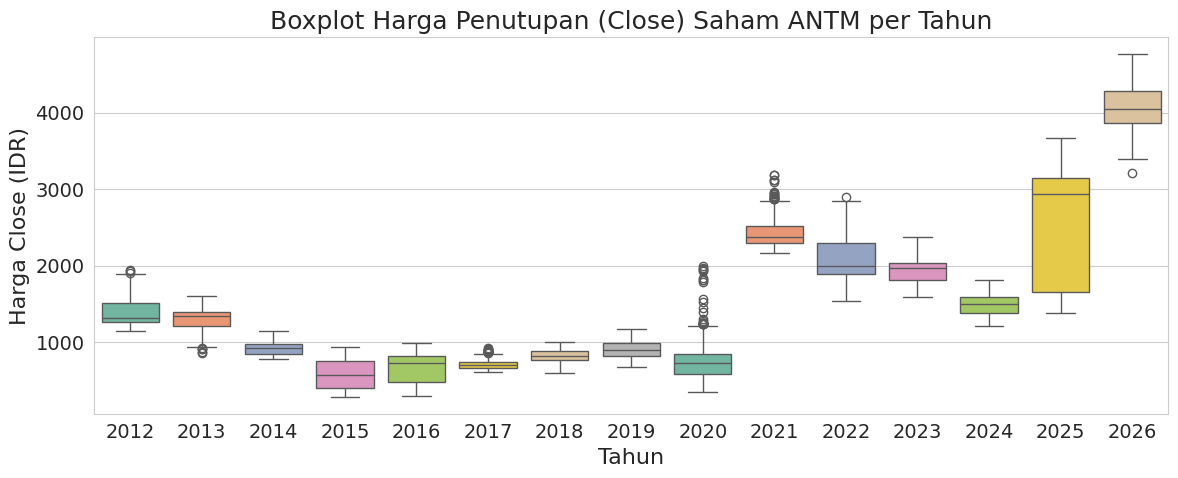

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df_box = df.copy()
df_box["Year"] = df_box.index.year

plt.figure(figsize=(12, 5))
sns.boxplot(x="Year", y="Close", data=df_box, palette="Set2")
plt.title("Boxplot Harga Penutupan (Close) Saham ANTM per Tahun")
plt.xlabel("Tahun")
plt.ylabel("Harga Close (IDR)")
plt.tight_layout()
plt.show()


### 2.10 Coefficient of Variation (CV)

In [ ]:
cv_per_year = df_box.groupby("Year")["Close"].agg(["mean", "std"])
cv_per_year["CV in %"] = (cv_per_year["std"] / cv_per_year["mean"]) * 100
cv_per_year

,mean,std,CV in %
Year,,,
2012,1413.990148,220.650119,15.604785
2013,1296.131148,164.954487,12.726682
2014,917.389344,81.276696,8.859564
2015,583.709016,200.567696,34.360904
2016,674.178862,198.463096,29.437751
2017,711.008403,66.248413,9.317529
2018,812.354167,83.347709,10.260021
2019,904.530612,110.311055,12.195392
2020,791.760331,320.800335,40.517354


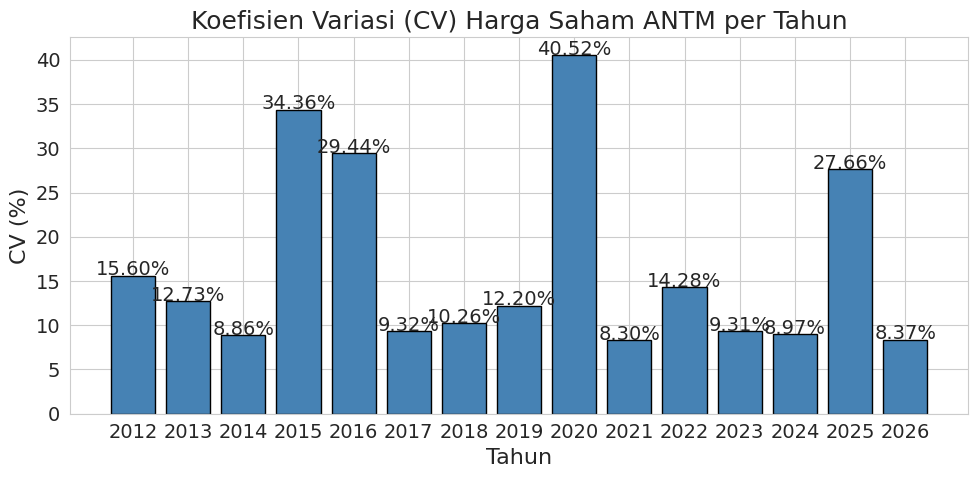

In [ ]:
plt.figure(figsize=(10, 5))
plt.bar(cv_per_year.index.astype(str), cv_per_year["CV in %"], color="steelblue", edgecolor="black")
plt.title("Koefisien Variasi (CV) Harga Saham ANTM per Tahun")
plt.xlabel("Tahun")
plt.ylabel("CV (%)")
for i, v in enumerate(cv_per_year["CV in %"]):
    plt.text(i, v + 0.05, f"{v:.2f}%", ha="center")
plt.tight_layout()
plt.show()

### 2.11 Correlation Matrix (Mean, Std, CV)

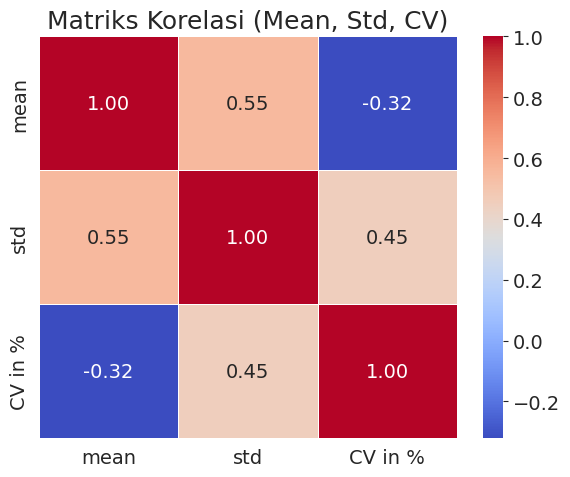

In [ ]:
plt.figure(figsize=(6, 5))
sns.heatmap(cv_per_year.corr(), annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Matriks Korelasi (Mean, Std, CV)")
plt.tight_layout()
plt.show()

## 3. Data Preparation

### 3.1 Data Cleaning

In [ ]:
print("Sebelum dropna:", df.shape)
df = df.dropna()
print("Sesudah dropna:", df.shape)

Sebelum dropna: (3390, 9)
Sesudah dropna: (3390, 9)


### 3.2 Daily Return

In [ ]:
df["Daily Return"] = df["Close"].pct_change()
df[["Close", "Daily Return"]].head(10)

,Close,Daily Return
2012-03-02,1940.0,NaN
2012-03-05,1930.0,-0.005155
2012-03-06,1900.0,-0.015544
2012-03-07,1850.0,-0.026316
2012-03-08,1870.0,0.010811
2012-03-09,1880.0,0.005348
2012-03-12,1870.0,-0.005319
2012-03-13,1870.0,0.000000
2012-03-14,1890.0,0.010695
2012-03-15,1840.0,-0.026455


### 3.3 Daily Return Chart

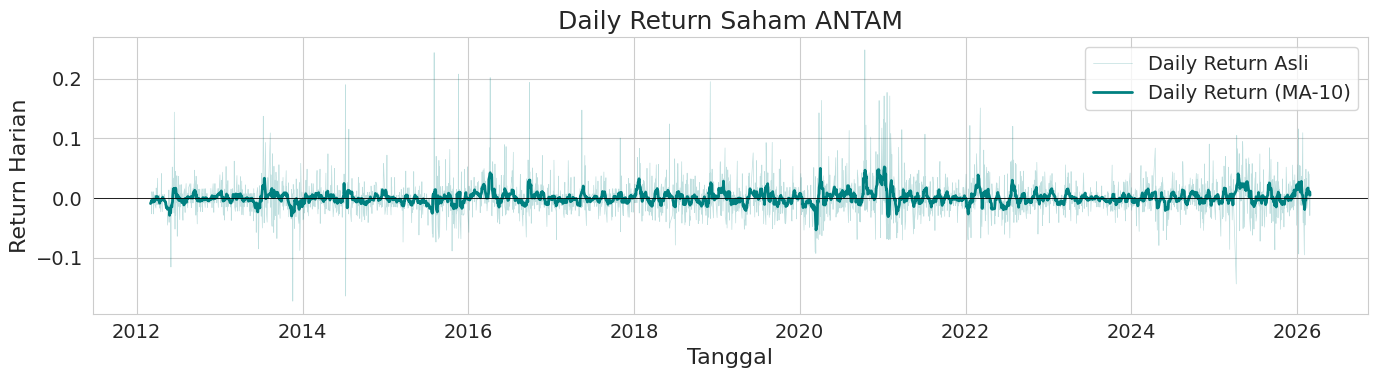

In [ ]:
plt.figure(figsize=(14, 4))
plt.plot(df.index, df["Daily Return"], color="teal", linewidth=0.5, alpha=0.25, label="Daily Return Asli")
dr_smooth = df["Daily Return"].rolling(window=10, center=True, min_periods=1).mean()
plt.plot(df.index, dr_smooth, color="teal", linewidth=2, label="Daily Return (MA-10)")
plt.axhline(0, color="black", linewidth=0.6)
plt.title("Daily Return Saham ANTAM")
plt.xlabel("Tanggal")
plt.ylabel("Return Harian")
plt.legend()
plt.tight_layout()
plt.show()


### 3.4 Daily Return Distribution and Mean

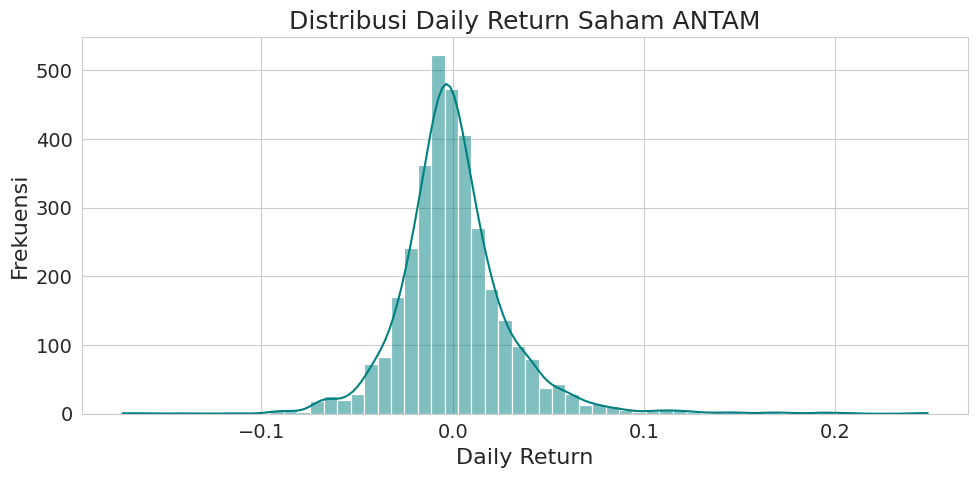

In [ ]:
plt.figure(figsize=(10, 5))
sns.histplot(df["Daily Return"].dropna(), bins=60, kde=True, color="teal")
plt.title("Distribusi Daily Return Saham ANTAM")
plt.xlabel("Daily Return")
plt.ylabel("Frekuensi")
plt.tight_layout()
plt.show()

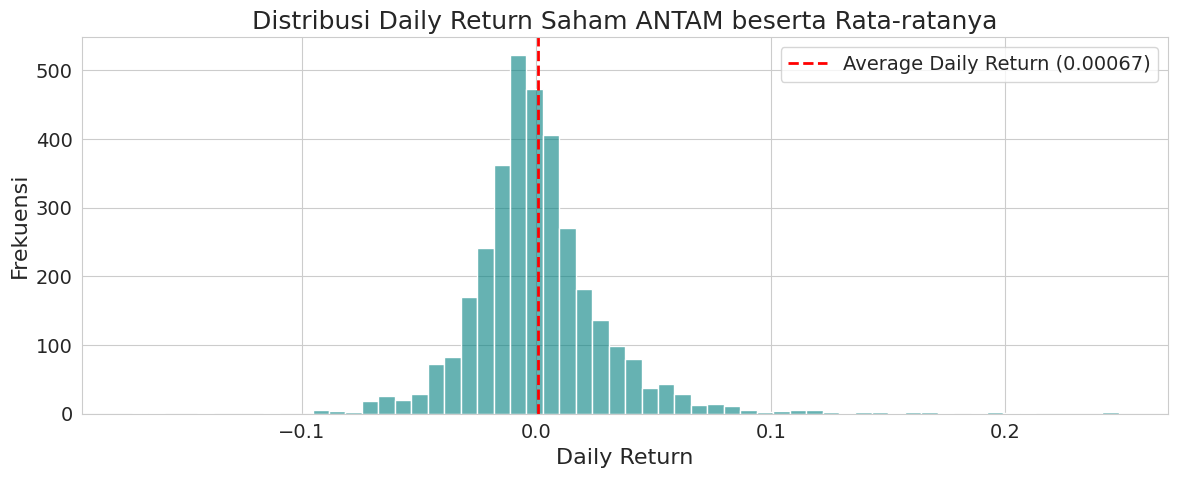

In [ ]:
avg_daily_return = df["Daily Return"].mean()

plt.figure(figsize=(12, 5))

# Histogram saja, tanpa kurva KDE (kde=False)
sns.histplot(df["Daily Return"].dropna(), bins=60, kde=False, color="teal", alpha=0.6)

# Garis Average Daily Return
plt.axvline(avg_daily_return, color="red", linestyle="--", linewidth=2,
            label=f"Average Daily Return ({avg_daily_return:.5f})")

plt.title("Distribusi Daily Return Saham ANTAM beserta Rata-ratanya")
plt.xlabel("Daily Return")
plt.ylabel("Frekuensi")
plt.legend()
plt.tight_layout()
plt.show()

### 3.5 Moving Averages (SMA-50 and SMA-200)

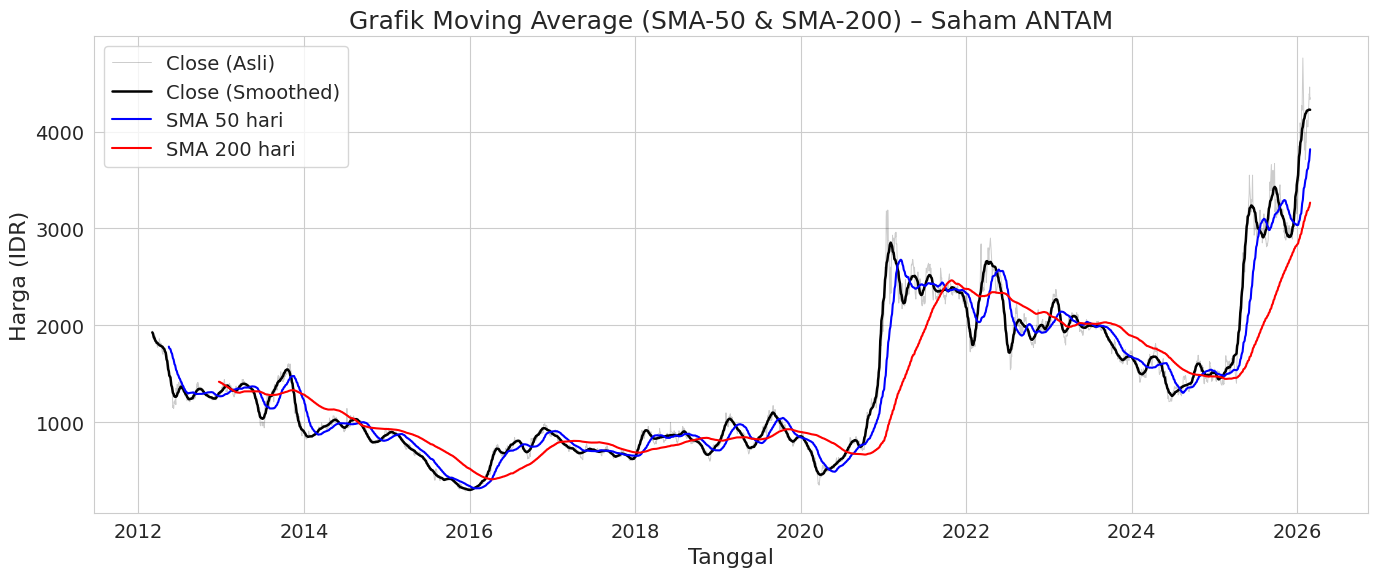

In [ ]:
df["SMA_50"]  = df["Close"].rolling(window=50).mean()
df["SMA_200"] = df["Close"].rolling(window=200).mean()

n_c = len(df["Close"].dropna())
wl_c = 51 if n_c >= 51 else (n_c if n_c % 2 == 1 else n_c - 1)
close_smooth = savgol_filter(df["Close"].values, window_length=wl_c, polyorder=3)

plt.figure(figsize=(14, 6))
plt.plot(df.index, df["Close"],   label="Close (Asli)",    color="black", alpha=0.2, linewidth=0.7)
plt.plot(df.index, close_smooth,  label="Close (Smoothed)", color="black", linewidth=1.8)
plt.plot(df.index, df["SMA_50"],  label="SMA 50 hari",     color="blue")
plt.plot(df.index, df["SMA_200"], label="SMA 200 hari",    color="red")
plt.title("Grafik Moving Average (SMA-50 & SMA-200) – Saham ANTAM")
plt.xlabel("Tanggal")
plt.ylabel("Harga (IDR)")
plt.legend()
plt.tight_layout()
plt.show()


### 3.6 Relative Strength Index (RSI)

In [ ]:
def compute_rsi(series, period=14):
    delta = series.diff()
    gain = delta.where(delta > 0, 0.0)
    loss = -delta.where(delta < 0, 0.0)
    avg_gain = gain.rolling(window=period, min_periods=period).mean()
    avg_loss = loss.rolling(window=period, min_periods=period).mean()
    rs = avg_gain / avg_loss
    rsi = 100 - (100 / (1 + rs))
    return rsi

df["RSI"] = compute_rsi(df["Close"], period=14)
df[["Close", "RSI"]].tail(10)

,Close,RSI
2026-02-12,4120.0,46.288210
2026-02-13,4050.0,31.216931
2026-02-18,4050.0,33.908046
2026-02-19,4230.0,44.508671
2026-02-20,4220.0,46.951220
2026-02-23,4390.0,55.294118
2026-02-24,4380.0,71.755725
2026-02-25,4460.0,70.866142
2026-02-26,4330.0,62.686567
2026-02-27,4350.0,72.881356


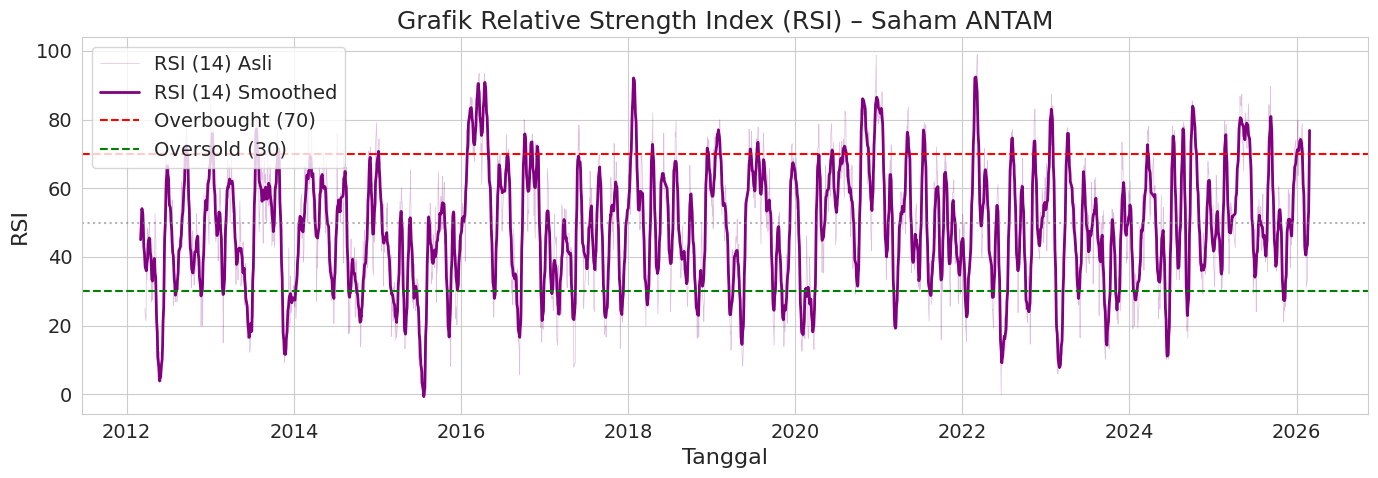

In [ ]:
n_r = len(df["RSI"].dropna())
wl_r = 21 if n_r >= 21 else (n_r if n_r % 2 == 1 else n_r - 1)
rsi_vals = df["RSI"].fillna(50).values
rsi_smooth = savgol_filter(rsi_vals, window_length=wl_r, polyorder=3)

plt.figure(figsize=(14, 5))
plt.plot(df.index, df["RSI"],  color="purple", linewidth=0.5, alpha=0.25, label="RSI (14) Asli")
plt.plot(df.index, rsi_smooth, color="purple", linewidth=2,   label="RSI (14) Smoothed")
plt.axhline(70, linestyle="--", color="red",   label="Overbought (70)")
plt.axhline(30, linestyle="--", color="green", label="Oversold (30)")
plt.axhline(50, linestyle=":",  color="gray",  alpha=0.6)
plt.title("Grafik Relative Strength Index (RSI) – Saham ANTAM")
plt.xlabel("Tanggal")
plt.ylabel("RSI")
plt.legend()
plt.tight_layout()
plt.show()


### 3.7 Feature Selection

In [ ]:
df["SMA_50"]  = df["Close"].rolling(window=50,  min_periods=20).mean()
df["SMA_200"] = df["Close"].rolling(window=200, min_periods=50).mean()
df["RSI"] = compute_rsi(df["Close"], period=14)

df_model = df.dropna(subset=["SMA_50", "SMA_200", "RSI"]).copy()
df_model["Target_Return"] = df_model["Close"].pct_change().shift(-1)
df_model = df_model.dropna(subset=["Target_Return"])

features = [
    "Open", "High", "Low", "Volume",
    "SMA_50", "SMA_200", "RSI",
    "Gold_Close", "Nickel_Close", "USDIDR_Close"
]

target = "Target_Return"

X = df_model[features]
y = df_model[target]
close_price = df_model["Close"]

print("Jumlah fitur  :", len(features))
print("Jumlah sampel :", X.shape[0])
print("Target        : Return (persentase perubahan harga)")

Jumlah fitur  : 10
Jumlah sampel : 3340
Target        : Return (persentase perubahan harga)


### 3.7.1 Gold and Nickel Correlation with ANTM Price

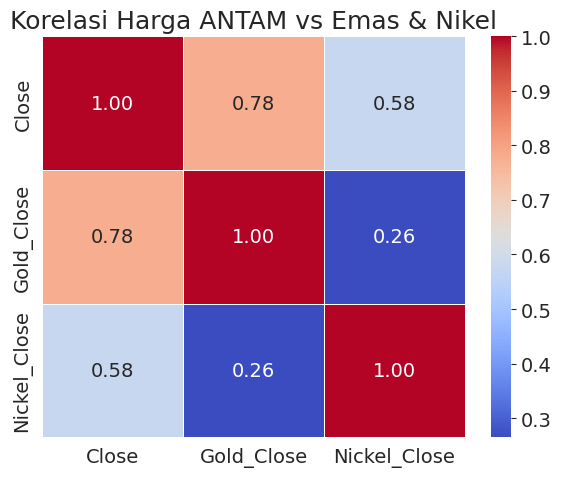

In [ ]:
plt.figure(figsize=(6, 5))
sns.heatmap(
    df_model[["Close", "Gold_Close", "Nickel_Close"]].corr(),
    annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5
)
plt.title("Korelasi Harga ANTAM vs Emas & Nikel")
plt.tight_layout()
plt.show()


### 3.7.2 Price Trends: ANTM, Gold, and Nickel

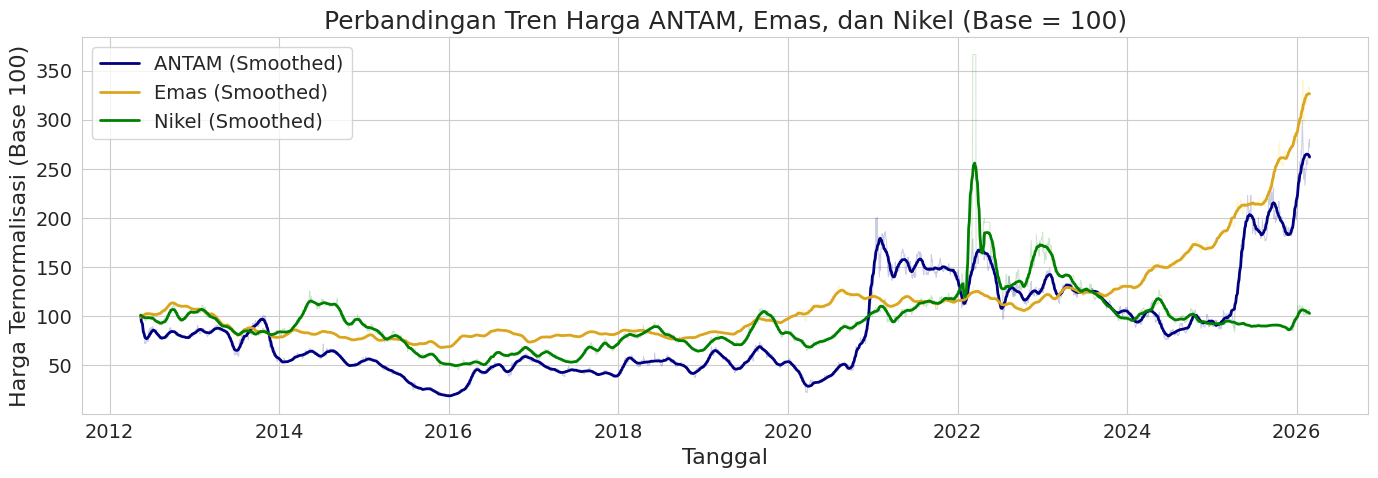

In [ ]:
df_trend = df_model[["Close", "Gold_Close", "Nickel_Close"]].copy()
df_trend = df_trend / df_trend.iloc[0] * 100

n_t = len(df_trend)
wl_t = 51 if n_t >= 51 else (n_t if n_t % 2 == 1 else n_t - 1)
antm_s   = savgol_filter(df_trend["Close"].values,        window_length=wl_t, polyorder=3)
gold_s   = savgol_filter(df_trend["Gold_Close"].values,   window_length=wl_t, polyorder=3)
nickel_s = savgol_filter(df_trend["Nickel_Close"].values, window_length=wl_t, polyorder=3)

plt.figure(figsize=(14, 5))
plt.plot(df_trend.index, df_trend["Close"],        color="navy",  alpha=0.2, linewidth=0.7)
plt.plot(df_trend.index, df_trend["Gold_Close"],   color="gold",  alpha=0.2, linewidth=0.7)
plt.plot(df_trend.index, df_trend["Nickel_Close"], color="green", alpha=0.2, linewidth=0.7)
plt.plot(df_trend.index, antm_s,   label="ANTAM (Smoothed)",  color="navy",  linewidth=2)
plt.plot(df_trend.index, gold_s,   label="Emas (Smoothed)",   color="goldenrod", linewidth=2)
plt.plot(df_trend.index, nickel_s, label="Nikel (Smoothed)",  color="green", linewidth=2)
plt.title("Perbandingan Tren Harga ANTAM, Emas, dan Nikel (Base = 100)")
plt.xlabel("Tanggal")
plt.ylabel("Harga Ternormalisasi (Base 100)")
plt.legend()
plt.tight_layout()
plt.show()


### 3.8 Feature Correlation Heatmap

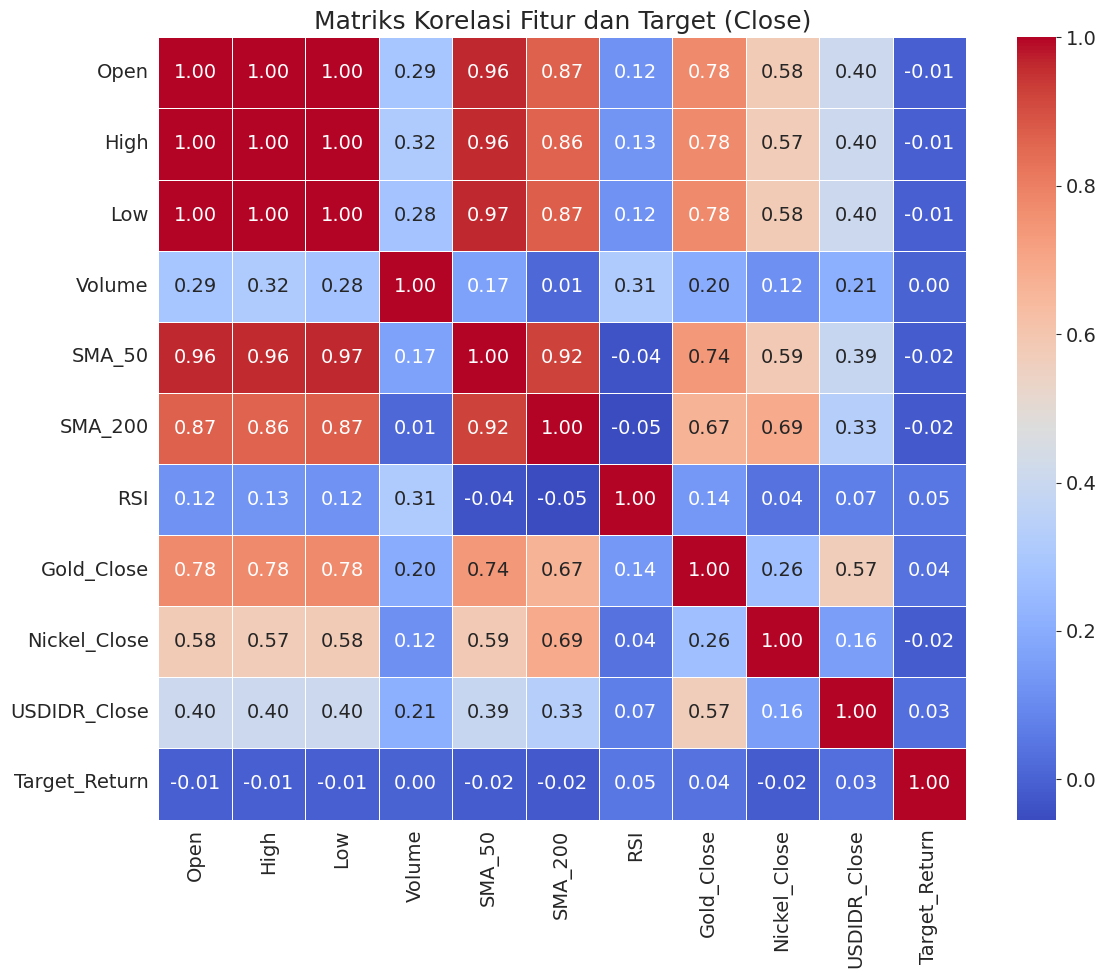

In [ ]:
plt.figure(figsize=(12, 10))
sns.heatmap(
    df_model[features + [target]].corr(),
    annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5
)
plt.title("Matriks Korelasi Fitur dan Target (Close)")
plt.tight_layout()
plt.show()

### 3.9 Train-Test Split (80:20)

In [ ]:
split_idx = int(len(X) * 0.8)
X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]
close_train, close_test = close_price.iloc[:split_idx], close_price.iloc[split_idx:]

total_n = len(X)
n_train = X_train.shape[0]
n_test  = X_test.shape[0]

print("Jumlah total sampel setelah feature engineering & dropna:", total_n)
print("Jumlah data latih (80%) :", n_train, f"({n_train/total_n:.1%})")
print("Jumlah data uji   (20%) :", n_test,  f"({n_test/total_n:.1%})")
print()
print(">> PENTING: salin angka-angka di atas ke Abstrak dan Bab 4 skripsi")
print("   agar keduanya konsisten dengan hasil aktual notebook ini.")


Jumlah total sampel setelah feature engineering & dropna: 3340
Jumlah data latih (80%) : 2672 (80.0%)
Jumlah data uji   (20%) : 668 (20.0%)

>> PENTING: salin angka-angka di atas ke Abstrak dan Bab 4 skripsi
   agar keduanya konsisten dengan hasil aktual notebook ini.


In [ ]:
def directional_accuracy(hasil_df, price_before):
    """
    Mengukur seberapa sering model menebak ARAH pergerakan harga
    (naik/turun) dengan benar, dibandingkan harga pada hari sebelumnya
    (price_before). MAPE yang rendah tidak menjamin arah yang benar,
    sehingga metrik ini penting untuk konteks keputusan investasi.

    Penyelarasan dilakukan secara POSISIONAL (bukan .reindex() berbasis
    label index), karena hasil_df selalu dibentuk dari
    price_before.shift(-1) lalu dropna() -- yaitu memotong tepat satu
    baris terakhir tanpa mengubah urutan sisanya. Dengan begitu,
    price_before.iloc[:len(hasil_df)] SELALU berpadanan posisi dengan
    hasil_df, terlepas dari apakah index tanggalnya unik atau tidak.
    Pendekatan .reindex() sebelumnya rawan gagal dengan error
    'cannot reindex on an axis with duplicate labels' bila index tanggal
    memiliki duplikat (misalnya akibat baris tanggal ganda pada data
    sumber).
    """
    aligned_before = price_before.iloc[:len(hasil_df)].values
    actual_dir = np.sign(hasil_df["Aktual"].values - aligned_before)
    pred_dir   = np.sign(hasil_df["Prediksi"].values - aligned_before)
    match = actual_dir == pred_dir
    return match.mean() * 100

### 3.10 Time-Series Cross-Validation (Walk-Forward K-Fold)

A single 80:20 split is vulnerable to bias, because ANTM market conditions
in 2012 differ substantially from 2020, 2022 or 2025 (financial crises,
commodity booms, and so on). To test whether model performance holds across
different market regimes, *walk-forward* cross-validation was applied using
`TimeSeriesSplit` with 5 folds.

Unlike ordinary random k-fold, `TimeSeriesSplit` does not shuffle the data:
each fold trains only on historical (past) data and tests on the data that
follows it (future), preserving chronological order and preventing
*data leakage*.

In [ ]:
N_SPLITS = 5
tscv = TimeSeriesSplit(n_splits=N_SPLITS)

cv_rows = []
for fold, (train_idx, test_idx) in enumerate(tscv.split(X), start=1):
    X_tr, X_te = X.iloc[train_idx], X.iloc[test_idx]
    y_tr, y_te = y.iloc[train_idx], y.iloc[test_idx]
    close_tr, close_te = close_price.iloc[train_idx], close_price.iloc[test_idx]

    period_start = X_te.index.min().date()
    period_end   = X_te.index.max().date()

    for model_name, model in [
        ("XGBoost", XGBRegressor(n_estimators=100, random_state=42)),
        ("Random Forest", RandomForestRegressor(n_estimators=100, max_depth=10, random_state=42)),
    ]:
        model.fit(X_tr, y_tr)
        ret_pred = model.predict(X_te)
        price_pred = close_te.values * (1 + ret_pred)

        hasil_fold = pd.DataFrame({
            "Aktual": close_te.shift(-1),
            "Prediksi": price_pred
        }, index=close_te.index).dropna()

        y_act = hasil_fold["Aktual"].values
        y_prd = hasil_fold["Prediksi"].values

        mape_fold = mean_absolute_percentage_error(y_act, y_prd) * 100
        da_fold = directional_accuracy(hasil_fold, close_te)

        cv_rows.append({
            "Fold": fold,
            "Periode Uji": f"{period_start} s.d. {period_end}",
            "Model": model_name,
            "Jumlah Data Uji": len(hasil_fold),
            "MAPE (%)": mape_fold,
            "Directional Accuracy (%)": da_fold
        })

cv_result = pd.DataFrame(cv_rows)
cv_result

,Fold,Periode Uji,Model,Jumlah Data Uji,MAPE (%),Directional Accuracy (%)
0,1,2014-09-04 s.d. 2016-12-06,XGBoost,555,4.423428,38.018018
1,1,2014-09-04 s.d. 2016-12-06,Random Forest,555,2.994137,44.684685
2,2,2016-12-07 s.d. 2019-04-01,XGBoost,555,2.311001,47.027027
3,2,2016-12-07 s.d. 2019-04-01,Random Forest,555,1.982155,44.324324
4,3,2019-04-02 s.d. 2021-07-15,XGBoost,555,4.236015,46.126126
5,3,2019-04-02 s.d. 2021-07-15,Random Forest,555,3.091504,45.945946
6,4,2021-07-16 s.d. 2023-10-25,XGBoost,555,3.008165,41.981982
7,4,2021-07-16 s.d. 2023-10-25,Random Forest,555,2.559978,38.738739
8,5,2023-10-26 s.d. 2026-02-26,XGBoost,555,4.310152,47.027027
9,5,2023-10-26 s.d. 2026-02-26,Random Forest,555,4.791631,47.027027


The mean and standard deviation of each model across all folds indicate how
stable its performance is across different market regimes. A large standard
deviation suggests inconsistent performance that depends heavily on the
specific market period.

In [ ]:
cv_summary = cv_result.groupby("Model")[["MAPE (%)", "Directional Accuracy (%)"]].agg(["mean", "std"])
cv_summary

MAPE (%)           Directional Accuracy (%)          
                   mean       std                     mean       std
Model                                                               
Random Forest  3.083881  1.050333                44.144144  3.205486
XGBoost        3.657752  0.946305                44.036036  3.959047

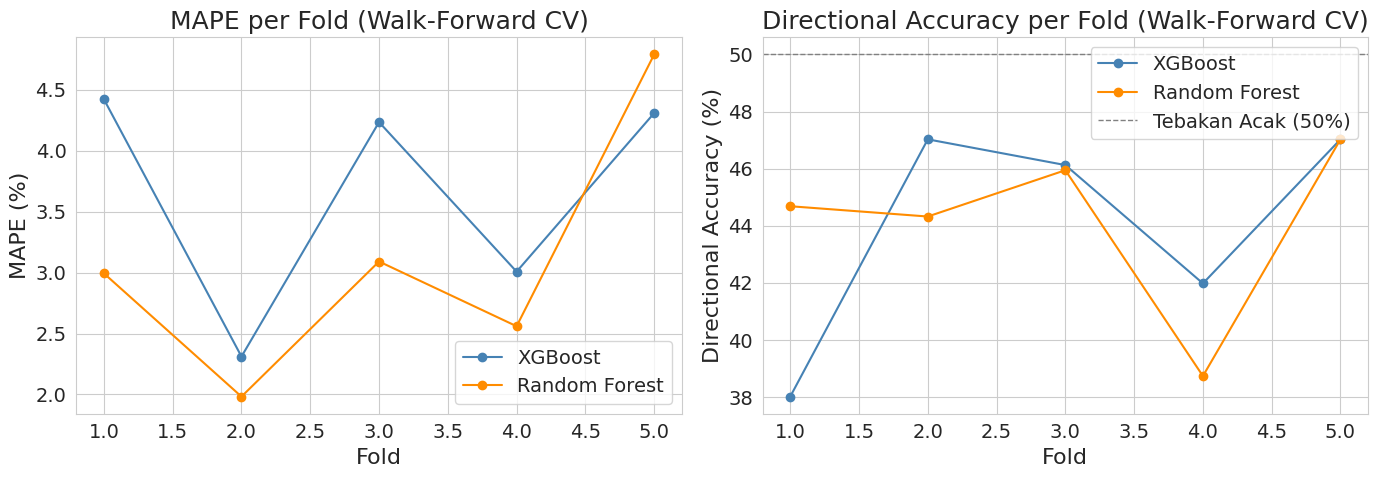

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for model_name, color in [("XGBoost", "steelblue"), ("Random Forest", "darkorange")]:
    sub = cv_result[cv_result["Model"] == model_name]
    axes[0].plot(sub["Fold"], sub["MAPE (%)"], marker="o", label=model_name, color=color)
    axes[1].plot(sub["Fold"], sub["Directional Accuracy (%)"], marker="o", label=model_name, color=color)

axes[0].set_title("MAPE per Fold (Walk-Forward CV)")
axes[0].set_xlabel("Fold"); axes[0].set_ylabel("MAPE (%)")
axes[0].legend()

axes[1].axhline(50, color="gray", linestyle="--", linewidth=1, label="Tebakan Acak (50%)")
axes[1].set_title("Directional Accuracy per Fold (Walk-Forward CV)")
axes[1].set_xlabel("Fold"); axes[1].set_ylabel("Directional Accuracy (%)")
axes[1].legend()

plt.tight_layout()
plt.show()

### 3.11 Hyperparameter Tuning

In [ ]:
from sklearn.model_selection import RandomizedSearchCV

# ============================================================
# Hyperparameter Tuning dengan RandomizedSearchCV + TimeSeriesSplit
# ============================================================
# TimeSeriesSplit dipakai (bukan KFold biasa) agar konsisten dengan
# validasi silang time-series pada Bab 3.7 -- setiap fold tuning tetap
# melatih hanya pada data historis (masa lalu) dan menguji pada data
# setelahnya (masa depan), sehingga tidak terjadi kebocoran data.

tscv_tuning = TimeSeriesSplit(n_splits=5)

# --- Search space XGBoost ---
xgb_param_dist = {
    "n_estimators":      [100, 200, 300, 500],
    "max_depth":         [3, 4, 5, 6, 8, 10],
    "learning_rate":     [0.01, 0.03, 0.05, 0.1, 0.2],
    "subsample":         [0.6, 0.8, 1.0],
    "colsample_bytree":  [0.6, 0.8, 1.0],
    "min_child_weight":  [1, 3, 5],
}

xgb_search = RandomizedSearchCV(
    estimator=XGBRegressor(random_state=42),
    param_distributions=xgb_param_dist,
    n_iter=30,                     # jumlah kombinasi acak yang dicoba
    scoring="neg_mean_absolute_percentage_error",
    cv=tscv_tuning,
    random_state=42,
    n_jobs=-1,
    verbose=1,
)
xgb_search.fit(X_train, y_train)

print("=== Hasil Tuning XGBoost ===")
print("Parameter terbaik :", xgb_search.best_params_)
print(f"Skor terbaik (MAPE): {-xgb_search.best_score_ * 100:.4f}%")
print()

# --- Search space Random Forest ---
rf_param_dist = {
    "n_estimators":      [100, 200, 300, 500],
    "max_depth":         [5, 8, 10, 15, 20, None],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf":  [1, 2, 4],
    "max_features":      ["sqrt", "log2", None],
}

rf_search = RandomizedSearchCV(
    estimator=RandomForestRegressor(random_state=42),
    param_distributions=rf_param_dist,
    n_iter=30,
    scoring="neg_mean_absolute_percentage_error",
    cv=tscv_tuning,
    random_state=42,
    n_jobs=-1,
    verbose=1,
)
rf_search.fit(X_train, y_train)

print("=== Hasil Tuning Random Forest ===")
print("Parameter terbaik :", rf_search.best_params_)
print(f"Skor terbaik (MAPE): {-rf_search.best_score_ * 100:.4f}%")

# Simpan parameter terbaik untuk dipakai di sel training final
best_xgb_params = xgb_search.best_params_
best_rf_params  = rf_search.best_params_

Fitting 5 folds for each of 30 candidates, totalling 150 fits
=== Hasil Tuning XGBoost ===
Parameter terbaik : {'subsample': 1.0, 'n_estimators': 100, 'min_child_weight': 3, 'max_depth': 4, 'learning_rate': 0.01, 'colsample_bytree': 0.8}
Skor terbaik (MAPE): 172189154831054.0312%

Fitting 5 folds for each of 30 candidates, totalling 150 fits
=== Hasil Tuning Random Forest ===
Parameter terbaik : {'n_estimators': 500, 'min_samples_split': 2, 'min_samples_leaf': 4, 'max_features': 'log2', 'max_depth': 5}
Skor terbaik (MAPE): 229528466215174.7188%


## 4. Modelling

### 4.1 XGBoost

In [ ]:
xgb_model = XGBRegressor(
    **best_xgb_params,
    random_state=42
)
xgb_model.fit(X_train, y_train)

ret_pred_xgb = xgb_model.predict(X_test)
pred_harga_xgb = close_test.values * (1 + ret_pred_xgb)

hasil_xgb = pd.DataFrame({
    "Aktual"  : close_test.shift(-1),
    "Prediksi": pred_harga_xgb
}, index=close_test.index).dropna()

y_actual_xgb = hasil_xgb["Aktual"].values
y_pred_xgb   = hasil_xgb["Prediksi"].values

print("XGBoost selesai dilatih.")
print("5 prediksi harga pertama (XGBoost):", y_pred_xgb[:5].round(2))

XGBoost selesai dilatih.
5 prediksi harga pertama (XGBoost): [2106.3  2046.12 2006.   1995.97 1975.91]


In [ ]:
print("Jumlah data uji  :", len(y_test))
print("Jumlah prediksi  :", len(y_pred_xgb))


Jumlah data uji  : 668
Jumlah prediksi  : 667


### 4.2 XGBoost Feature Importance

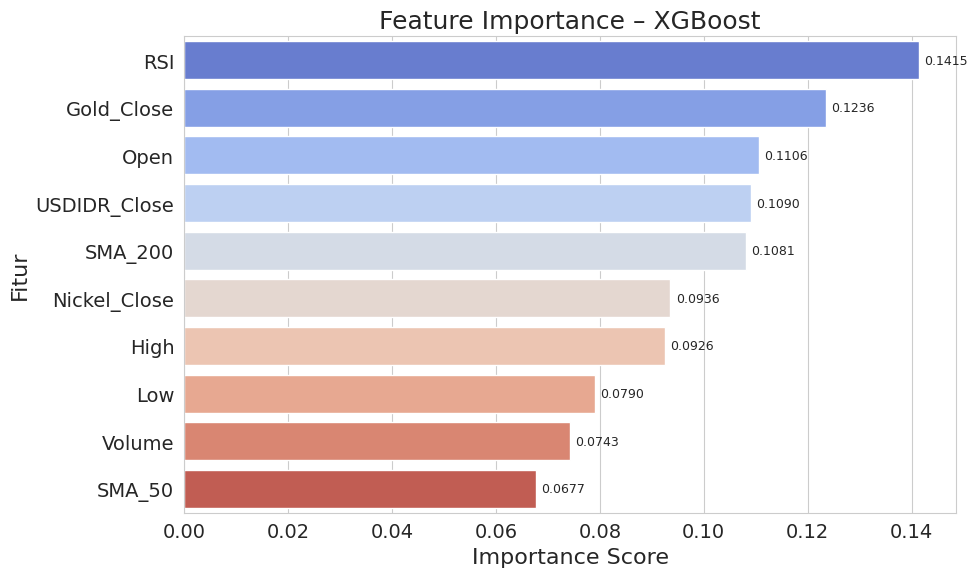

,Fitur,Importance
0,RSI,0.141467
1,Gold_Close,0.123584
2,Open,0.110561
3,USDIDR_Close,0.109010
4,SMA_200,0.108104
5,Nickel_Close,0.093584
6,High,0.092599
7,Low,0.079033
8,Volume,0.074318
9,SMA_50,0.067741


In [ ]:
feature_names_xgb = X_train.columns.tolist()

coef_df = pd.DataFrame({
    "Fitur"     : feature_names_xgb,
    "Importance": xgb_model.feature_importances_
}).sort_values("Importance", ascending=False).reset_index(drop=True)

plt.figure(figsize=(10, 6))
sns.barplot(x="Importance", y="Fitur", data=coef_df, palette="coolwarm")
for i, v in enumerate(coef_df["Importance"]):
    plt.text(v + 0.001, i, f"{v:.4f}", va="center", fontsize=9)
plt.title("Feature Importance – XGBoost")
plt.xlabel("Importance Score")
plt.tight_layout()
plt.show()

coef_df

### 4.3 Random Forest

In [ ]:
rf_model = RandomForestRegressor(**best_rf_params, random_state=42)
rf_model.fit(X_train, y_train)

ret_pred_rf = rf_model.predict(X_test)
pred_harga_rf = close_test.values * (1 + ret_pred_rf)

hasil_rf = pd.DataFrame({
    "Aktual"  : close_test.shift(-1),
    "Prediksi": pred_harga_rf
}, index=close_test.index).dropna()

y_actual_rf = hasil_rf["Aktual"].values
y_pred_rf   = hasil_rf["Prediksi"].values

print("Random Forest selesai dilatih.")
print("5 prediksi harga pertama (Random Forest):", y_pred_rf[:5].round(2))

Random Forest selesai dilatih.
5 prediksi harga pertama (Random Forest): [2106.98 2046.73 2006.38 1996.35 1976.28]


### 4.4 Random Forest Visualisation

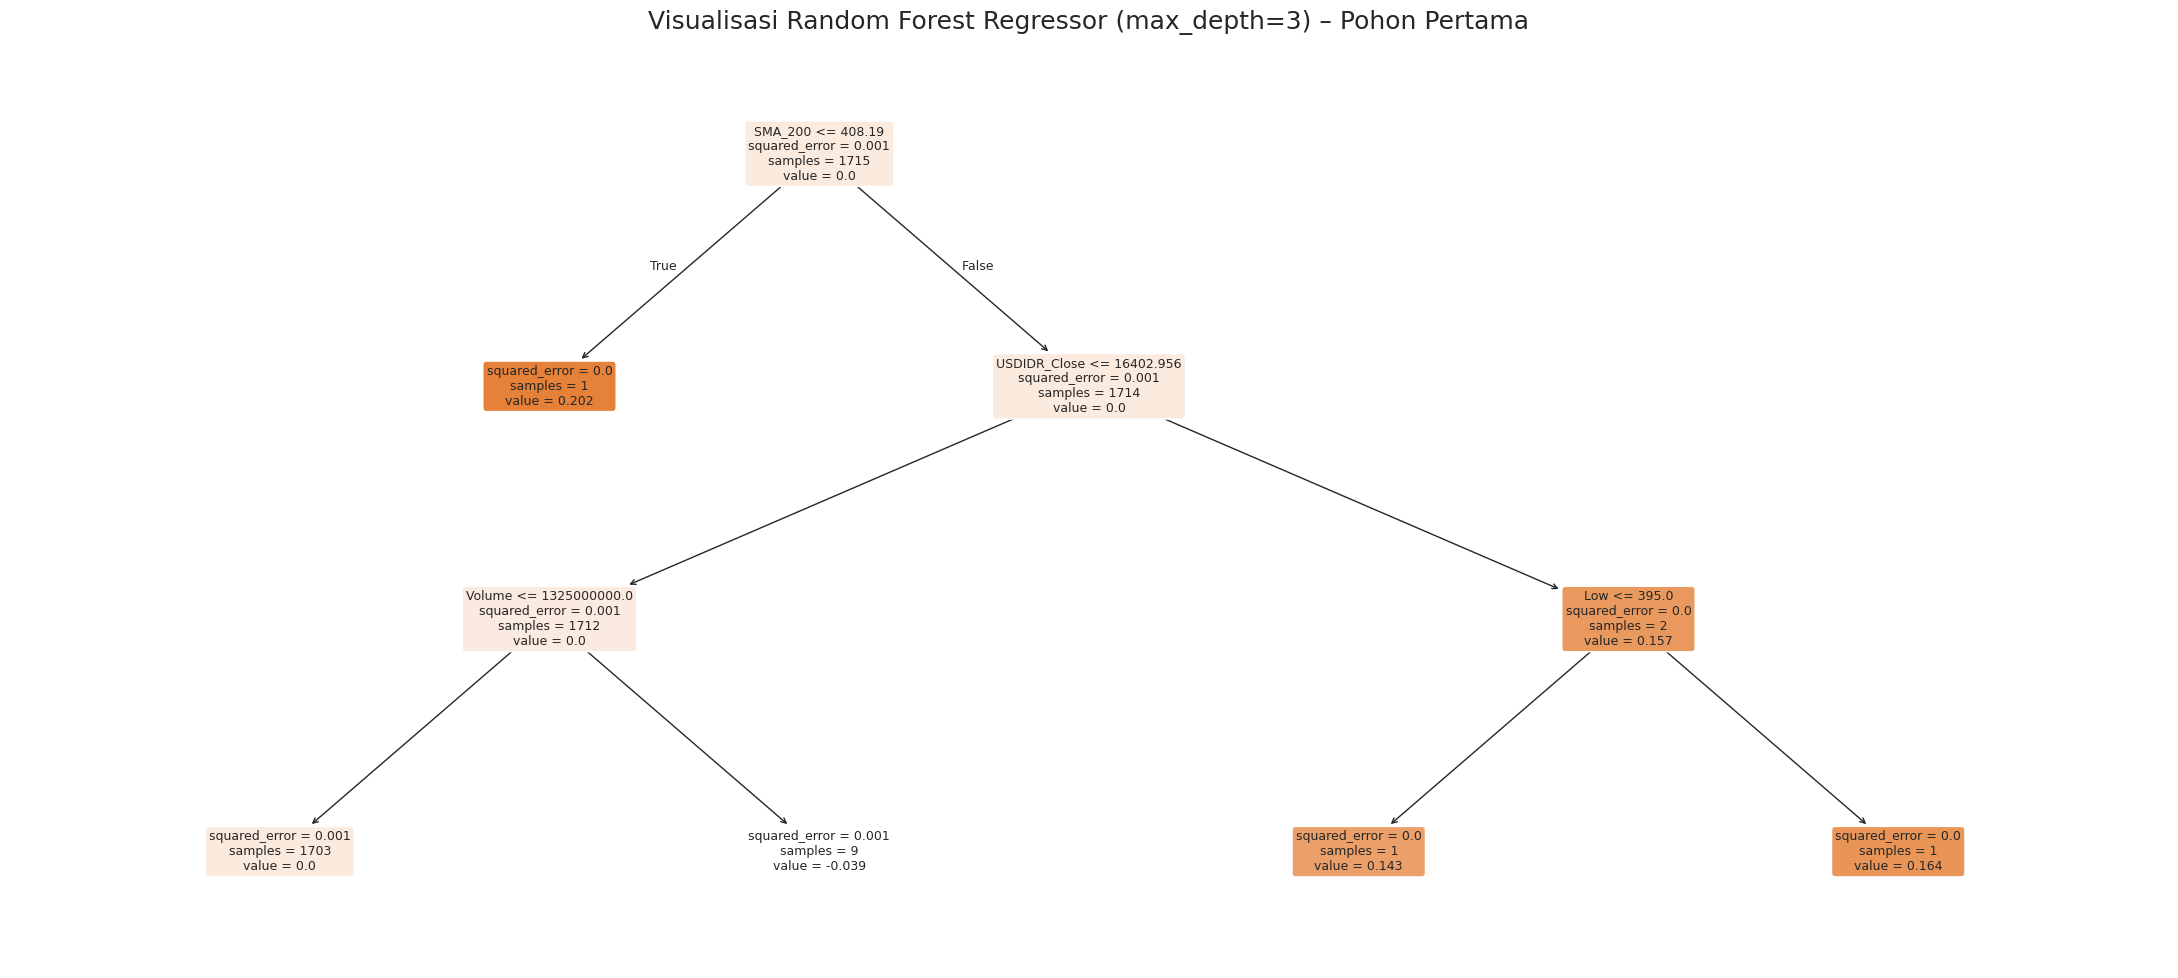

In [ ]:
from sklearn.tree import plot_tree

rf_vis = RandomForestRegressor(n_estimators=10, max_depth=3, random_state=42)
rf_vis.fit(X_train, y_train)

plt.figure(figsize=(22, 10))
plot_tree(
    rf_vis.estimators_[0],
    feature_names=X_train.columns.tolist(),
    filled=True, rounded=True, fontsize=9
)
plt.title("Visualisasi Random Forest Regressor (max_depth=3) – Pohon Pertama")
plt.tight_layout()
plt.show()

### 4.5 Random Forest Feature Importance

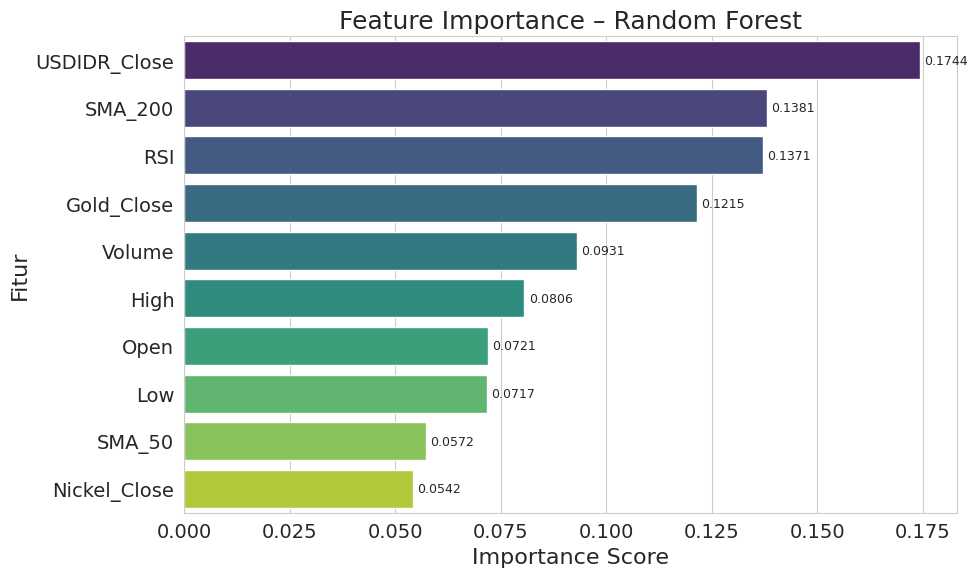

,Fitur,Importance
0,USDIDR_Close,0.174420
1,SMA_200,0.138081
2,RSI,0.137084
3,Gold_Close,0.121521
4,Volume,0.093074
5,High,0.080641
6,Open,0.072089
7,Low,0.071690
8,SMA_50,0.057219
9,Nickel_Close,0.054182


In [ ]:
feature_names_rf = X_train.columns.tolist()

importance_rf = pd.DataFrame({
    "Fitur"     : feature_names_rf,
    "Importance": rf_model.feature_importances_
}).sort_values("Importance", ascending=False).reset_index(drop=True)

plt.figure(figsize=(10, 6))
sns.barplot(x="Importance", y="Fitur", data=importance_rf, palette="viridis")
for i, v in enumerate(importance_rf["Importance"]):
    plt.text(v + 0.001, i, f"{v:.4f}", va="center", fontsize=9)
plt.title("Feature Importance – Random Forest")
plt.xlabel("Importance Score")
plt.tight_layout()
plt.show()

importance_rf

## 4.6 Actual vs Predicted Comparison Table

In [ ]:
hasil_pred = pd.DataFrame({
    "Close (Aktual)": hasil_xgb["Aktual"],
    "XGBoost_Pred"  : hasil_xgb["Prediksi"],
    "RF_Pred"       : hasil_rf["Prediksi"]
}).sort_index()

pd.concat([hasil_pred.head(5), hasil_pred.tail(5)])

,Close (Aktual),XGBoost_Pred,RF_Pred
2023-05-10,2040.0,2106.295538,2106.982908
2023-05-11,2000.0,2046.115665,2046.730456
2023-05-12,1990.0,2005.995750,2006.384521
2023-05-15,1970.0,1995.965772,1996.354509
2023-05-16,1935.0,1975.905814,1976.284382
2026-02-19,4220.0,4186.427804,4272.006313
2026-02-20,4390.0,4174.565847,4262.106739
2026-02-23,4380.0,4342.735561,4432.400401
2026-02-24,4460.0,4319.460078,4417.918207
2026-02-25,4330.0,4398.354326,4497.779126


## 5. Model Evaluation (MAPE)

In [ ]:
mape_xgb = mean_absolute_percentage_error(y_actual_xgb, y_pred_xgb)
mape_rf  = mean_absolute_percentage_error(y_actual_rf, y_pred_rf)
print(f"MAPE XGBoost      : {mape_xgb*100:.4f}%")
print(f"MAPE Random Forest: {mape_rf*100:.4f}%")

MAPE XGBoost      : 2.0443%
MAPE Random Forest: 2.0902%


In [ ]:
def evaluate(y_true, y_pred, name, da=None):
    mape = mean_absolute_percentage_error(y_true, y_pred) * 100
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2   = r2_score(y_true, y_pred)
    print(f"=== {name} ===")
    print(f"MAPE                 : {mape:.4f} %")
    print(f"MAE                  : {mae:.4f}")
    print(f"RMSE                 : {rmse:.4f}")
    print(f"R²                   : {r2:.4f}")
    if da is not None:
        print(f"Directional Accuracy : {da:.2f} %  (persentase hari model menebak arah naik/turun dengan benar)")
    print()
    result = {"Model": name, "MAPE (%)": mape, "MAE": mae, "RMSE": rmse, "R²": r2}
    if da is not None:
        result["Directional Accuracy (%)"] = da
    return result

# Directional accuracy dihitung dengan membandingkan arah pergerakan harga
# prediksi terhadap harga aktual pada hari sebelumnya (close_test),
# bukan hanya kedekatan nilainya (MAPE)
da_xgb = directional_accuracy(hasil_xgb, close_test)
da_rf  = directional_accuracy(hasil_rf,  close_test)

res_xgb = evaluate(y_actual_xgb, y_pred_xgb, "XGBoost", da=da_xgb)
res_rf  = evaluate(y_actual_rf,  y_pred_rf,  "Random Forest", da=da_rf)

hasil = pd.DataFrame([res_xgb, res_rf])
hasil

=== XGBoost ===
MAPE                 : 2.0443 %
MAE                  : 47.3301
RMSE                 : 75.5628
R²                   : 0.9913
Directional Accuracy : 43.78 %  (persentase hari model menebak arah naik/turun dengan benar)

=== Random Forest ===
MAPE                 : 2.0902 %
MAE                  : 47.2467
RMSE                 : 74.0025
R²                   : 0.9916
Directional Accuracy : 45.13 %  (persentase hari model menebak arah naik/turun dengan benar)



,Model,MAPE (%),MAE,RMSE,R²,Directional Accuracy (%)
0,XGBoost,2.044303,47.330060,75.562796,0.991264,43.778111
1,Random Forest,2.090218,47.246655,74.002490,0.991621,45.127436


In [ ]:
# Tabel evaluasi lengkap: MAPE, MAE, RMSE, R², dan Directional Accuracy
# (sebelumnya kolom-kolom ini sudah dihitung oleh evaluate() tetapi
# di-drop sebelum ditulis ke laporan, sehingga hanya MAPE yang tampil.
# Sekarang seluruh metrik ditampilkan agar sesuai dengan klaim "4 metrik
# evaluasi" pada Bab 3/Bab 4.)
tabel_eval = hasil.copy()
tabel_eval["MAPE (%)"] = tabel_eval["MAPE (%)"].apply(lambda x: f"{x:.4f}%")
tabel_eval["MAE"] = tabel_eval["MAE"].apply(lambda x: f"{x:.4f}")
tabel_eval["RMSE"] = tabel_eval["RMSE"].apply(lambda x: f"{x:.4f}")
tabel_eval["R²"] = tabel_eval["R²"].apply(lambda x: f"{x:.4f}")
if "Directional Accuracy (%)" in tabel_eval.columns:
    tabel_eval["Directional Accuracy (%)"] = tabel_eval["Directional Accuracy (%)"].apply(lambda x: f"{x:.2f}%")
tabel_eval


,Model,MAPE (%),MAE,RMSE,R²,Directional Accuracy (%)
0,XGBoost,2.0443%,47.3301,75.5628,0.9913,43.78%
1,Random Forest,2.0902%,47.2467,74.0025,0.9916,45.13%


In [ ]:
from sklearn.metrics import confusion_matrix

print("="*70)
print("DIAGNOSTIK DIRECTIONAL ACCURACY")
print("="*70)

def to_binary_direction(hasil_df, price_before):
    aligned_before = price_before.iloc[:len(hasil_df)].values
    actual_dir = (hasil_df["Aktual"].values - aligned_before) > 0
    pred_dir   = (hasil_df["Prediksi"].values - aligned_before) > 0
    return actual_dir.astype(int), pred_dir.astype(int)

for name, hasil_df in [("XGBoost", hasil_xgb), ("Random Forest", hasil_rf)]:
    print(f"\n--- {name} ---")
    y_true_dir, y_pred_dir = to_binary_direction(hasil_df, close_test)

    # 1. Uji balik prediksi
    da_normal = (y_true_dir == y_pred_dir).mean() * 100
    da_inverted = (y_true_dir == (1 - y_pred_dir)).mean() * 100
    print(f"1) DA normal   : {da_normal:.2f}%")
    print(f"   DA dibalik  : {da_inverted:.2f}%")

    # 2. Confusion matrix
    cm = confusion_matrix(y_true_dir, y_pred_dir)
    print(f"2) Confusion Matrix [baris=aktual, kolom=prediksi, 0=turun,1=naik]:")
    print(f"   {cm.tolist()}")
    print(f"   Distribusi prediksi -> {pd.Series(y_pred_dir).value_counts(normalize=True).to_dict()}")
    print(f"   Distribusi aktual   -> {pd.Series(y_true_dir).value_counts(normalize=True).to_dict()}")

    # 3. Random guessing baseline
    rng = np.random.default_rng(42)
    da_randoms = [(y_true_dir == rng.choice([0,1], size=len(y_true_dir))).mean()*100 for _ in range(200)]
    print(f"3) Random guessing DA (rata-rata 200x): {np.mean(da_randoms):.2f}% (std {np.std(da_randoms):.2f})")

DIAGNOSTIK DIRECTIONAL ACCURACY

--- XGBoost ---
1) DA normal   : 44.83%
   DA dibalik  : 55.17%
2) Confusion Matrix [baris=aktual, kolom=prediksi, 0=turun,1=naik]:
   [[97, 266], [102, 202]]
   Distribusi prediksi -> {1: 0.7016491754122939, 0: 0.2983508245877061}
   Distribusi aktual   -> {0: 0.5442278860569715, 1: 0.45577211394302847}
3) Random guessing DA (rata-rata 200x): 49.83% (std 1.97)

--- Random Forest ---
1) DA normal   : 45.43%
   DA dibalik  : 54.57%
2) Confusion Matrix [baris=aktual, kolom=prediksi, 0=turun,1=naik]:
   [[32, 331], [33, 271]]
   Distribusi prediksi -> {1: 0.9025487256371814, 0: 0.09745127436281859}
   Distribusi aktual   -> {0: 0.5442278860569715, 1: 0.45577211394302847}
3) Random guessing DA (rata-rata 200x): 49.83% (std 1.97)


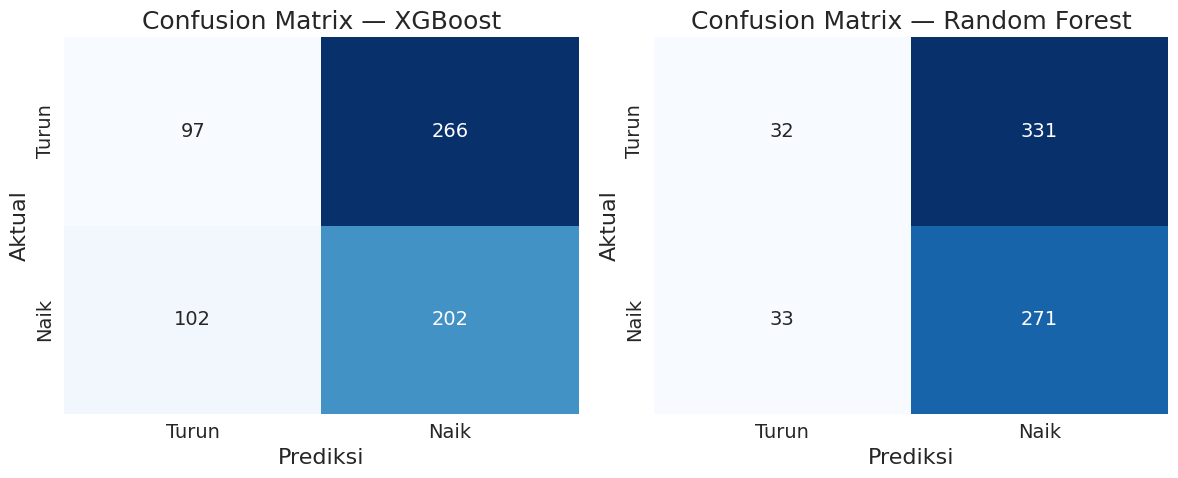

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, (name, hasil_df) in zip(axes, [("XGBoost", hasil_xgb), ("Random Forest", hasil_rf)]):
    y_true_dir, y_pred_dir = to_binary_direction(hasil_df, close_test)
    cm = confusion_matrix(y_true_dir, y_pred_dir)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False,
                xticklabels=["Turun", "Naik"], yticklabels=["Turun", "Naik"], ax=ax)
    ax.set_title(f"Confusion Matrix — {name}")
    ax.set_xlabel("Prediksi"); ax.set_ylabel("Aktual")

plt.tight_layout()
plt.savefig("confusion_matrix_directional.png", dpi=150)
plt.show()

### 4.7 Directional Accuracy Correction — Direction Classification with Detrended Features

Diagnostics in the preceding cell showed that both models were biased towards
predicting an "up" direction (XGBoost 70%, Random Forest 90%), because the features
used were **absolute price levels** (Open, High, Low, SMA, Gold_Close, Nickel_Close,
USDIDR_Close), which carry long-term trend information. The models learned that
"ANTM prices tend to rise" rather than the underlying daily direction pattern.

The correction applied two steps: **detrending** (converting all features into
relative returns/ratios) and **class balancing** (`scale_pos_weight` / `class_weight`).

In [ ]:
# ============================================================================
# 4.5 PERBAIKAN DIRECTIONAL ACCURACY — Klasifikasi Arah dengan Fitur Detrended
# ============================================================================
# Diagnostik sebelumnya menunjukkan model bias memprediksi arah "naik" karena
# fitur harga absolut (Open/High/Low/SMA/Gold/Nickel/USDIDR) membawa informasi
# TREN JANGKA PANJANG. Model belajar "harga cenderung naik" alih-alih pola arah
# harian. Perbaikan dilakukan dengan dua langkah:
#   1. DETRENDING — semua fitur diubah menjadi return/rasio relatif, sehingga
#      tidak ada lagi level harga absolut yang membawa bias tren.
#   2. CLASS BALANCING — scale_pos_weight (XGBoost) & class_weight (RF) agar
#      model tidak condong ke kelas mayoritas.

from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn.model_selection import TimeSeriesSplit

df_dir = df_model.copy()

# --- Fitur detrended: semua dalam bentuk return / rasio relatif ---
df_dir["ret_1"]      = df_dir["Close"].pct_change(1)
df_dir["ret_5"]      = df_dir["Close"].pct_change(5)
df_dir["ret_10"]     = df_dir["Close"].pct_change(10)
df_dir["vol_10"]     = df_dir["Close"].pct_change().rolling(10).std()
df_dir["hl_range"]   = (df_dir["High"] - df_dir["Low"]) / df_dir["Close"]
df_dir["co_ret"]     = (df_dir["Close"] - df_dir["Open"]) / df_dir["Open"]
df_dir["sma50_rel"]  = df_dir["Close"] / df_dir["SMA_50"] - 1
df_dir["sma200_rel"] = df_dir["Close"] / df_dir["SMA_200"] - 1
df_dir["rsi_n"]      = df_dir["RSI"] / 100
df_dir["vol_chg"]    = df_dir["Volume"].pct_change().replace([np.inf, -np.inf], np.nan)
df_dir["gold_ret"]   = df_dir["Gold_Close"].pct_change()
df_dir["nickel_ret"] = df_dir["Nickel_Close"].pct_change()
df_dir["usd_ret"]    = df_dir["USDIDR_Close"].pct_change()

FITUR_DETREND = ["ret_1", "ret_5", "ret_10", "vol_10", "hl_range", "co_ret",
                 "sma50_rel", "sma200_rel", "rsi_n", "vol_chg",
                 "gold_ret", "nickel_ret", "usd_ret"]

df_dir = df_dir.replace([np.inf, -np.inf], np.nan).dropna(subset=FITUR_DETREND + ["Target_Return"])

X_dir = df_dir[FITUR_DETREND]
y_dir = (df_dir["Target_Return"] > 0).astype(int)   # 1 = naik, 0 = turun

split_dir = int(len(X_dir) * 0.8)
X_dir_train, X_dir_test = X_dir.iloc[:split_dir], X_dir.iloc[split_dir:]
y_dir_train, y_dir_test = y_dir.iloc[:split_dir].values, y_dir.iloc[split_dir:].values

# Bobot kelas agar model tidak condong ke kelas mayoritas
spw = (y_dir_train == 0).sum() / max((y_dir_train == 1).sum(), 1)

print(f"Jumlah fitur detrended : {len(FITUR_DETREND)}")
print(f"Data latih / uji       : {len(X_dir_train)} / {len(X_dir_test)}")
print(f"Distribusi arah latih  : naik {y_dir_train.mean():.1%}  ->  scale_pos_weight = {spw:.3f}")
print(f"Distribusi arah uji    : naik {y_dir_test.mean():.1%}\n")

model_dir = {
    "XGBoost (klasifikasi arah)": XGBClassifier(
        n_estimators=300, max_depth=3, learning_rate=0.03,
        subsample=0.8, colsample_bytree=0.8,
        scale_pos_weight=spw, random_state=42, eval_metric="logloss"),
    "Random Forest (klasifikasi arah)": RandomForestClassifier(
        n_estimators=500, max_depth=5, min_samples_leaf=4,
        max_features="log2", class_weight="balanced", random_state=42),
}

hasil_dir = []
for nama, model in model_dir.items():
    model.fit(X_dir_train, y_dir_train)
    pred = model.predict(X_dir_test)
    da = accuracy_score(y_dir_test, pred) * 100
    cm = confusion_matrix(y_dir_test, pred)
    print(f"=== {nama} ===")
    print(f"Directional Accuracy : {da:.2f} %")
    print(f"Proporsi prediksi naik: {pred.mean():.1%}  (aktual: {y_dir_test.mean():.1%})")
    print(f"Confusion Matrix      : {cm.tolist()}\n")
    hasil_dir.append({"Model": nama, "Directional Accuracy (%)": da})

# --- Pembanding ---
rng_cmp = np.random.default_rng(42)
da_acak = np.mean([(y_dir_test == rng_cmp.choice([0, 1], size=len(y_dir_test))).mean() * 100
                    for _ in range(500)])
da_mayoritas = max(y_dir_test.mean(), 1 - y_dir_test.mean()) * 100
print(f"Baseline tebakan acak            : {da_acak:.2f} %")
print(f"Baseline selalu kelas mayoritas  : {da_mayoritas:.2f} %")

tabel_dir = pd.DataFrame(hasil_dir)
tabel_dir




Jumlah fitur detrended : 13
Data latih / uji       : 2664 / 666
Distribusi arah latih  : naik 39.8%  ->  scale_pos_weight = 1.513
Distribusi arah uji    : naik 45.8%

=== XGBoost (klasifikasi arah) ===
Directional Accuracy : 60.81 %
Proporsi prediksi naik: 40.8%  (aktual: 45.8%)
Confusion Matrix      : [[247, 114], [147, 158]]

=== Random Forest (klasifikasi arah) ===
Directional Accuracy : 62.01 %
Proporsi prediksi naik: 43.5%  (aktual: 45.8%)
Confusion Matrix      : [[242, 119], [134, 171]]

Baseline tebakan acak            : 50.06 %
Baseline selalu kelas mayoritas  : 54.20 %


,Model,Directional Accuracy (%)
0,XGBoost (klasifikasi arah),60.810811
1,Random Forest (klasifikasi arah),62.012012


In [ ]:
# ============================================================================
# Validasi walk-forward: memastikan perbaikan stabil lintas rezim pasar
# ============================================================================
print("\n" + "=" * 68)
print("VALIDASI WALK-FORWARD (TimeSeriesSplit 5-fold)")
print("=" * 68)

tscv_dir = TimeSeriesSplit(n_splits=5)
baris_cv = []
for nama, buat_model in [
    ("XGBoost", lambda w: XGBClassifier(n_estimators=300, max_depth=3, learning_rate=0.03,
                                         subsample=0.8, colsample_bytree=0.8,
                                         scale_pos_weight=w, random_state=42, eval_metric="logloss")),
    ("Random Forest", lambda w: RandomForestClassifier(n_estimators=500, max_depth=5, min_samples_leaf=4,
                                                        max_features="log2", class_weight="balanced",
                                                        random_state=42)),
]:
    print(f"\n--- {nama} ---")
    skor = []
    for k, (tr, te) in enumerate(tscv_dir.split(X_dir), start=1):
        ytr_k, yte_k = y_dir.iloc[tr].values, y_dir.iloc[te].values
        w = (ytr_k == 0).sum() / max((ytr_k == 1).sum(), 1)
        m = buat_model(w)
        m.fit(X_dir.iloc[tr], ytr_k)
        da_k = accuracy_score(yte_k, m.predict(X_dir.iloc[te])) * 100
        skor.append(da_k)
        periode = f"{df_dir.index[te].min().date()} s.d. {df_dir.index[te].max().date()}"
        print(f"  Fold {k} ({periode}): DA = {da_k:.2f} %")
        baris_cv.append({"Fold": k, "Periode": periode, "Model": nama,
                          "Directional Accuracy (%)": da_k})
    print(f"  Rata-rata: {np.mean(skor):.2f} % (std {np.std(skor):.2f})")

cv_dir_result = pd.DataFrame(baris_cv)
cv_dir_result



VALIDASI WALK-FORWARD (TimeSeriesSplit 5-fold)

--- XGBoost ---
  Fold 1 (2014-09-11 s.d. 2016-12-13): DA = 57.48 %
  Fold 2 (2016-12-14 s.d. 2019-04-05): DA = 54.41 %
  Fold 3 (2019-04-08 s.d. 2021-07-19): DA = 58.38 %
  Fold 4 (2021-07-21 s.d. 2023-10-26): DA = 59.64 %
  Fold 5 (2023-10-27 s.d. 2026-02-26): DA = 61.98 %
  Rata-rata: 58.38 % (std 2.49)

--- Random Forest ---
  Fold 1 (2014-09-11 s.d. 2016-12-13): DA = 55.50 %
  Fold 2 (2016-12-14 s.d. 2019-04-05): DA = 54.77 %
  Fold 3 (2019-04-08 s.d. 2021-07-19): DA = 59.46 %
  Fold 4 (2021-07-21 s.d. 2023-10-26): DA = 62.70 %
  Fold 5 (2023-10-27 s.d. 2026-02-26): DA = 61.98 %
  Rata-rata: 58.88 % (std 3.25)


,Fold,Periode,Model,Directional Accuracy (%)
0,1,2014-09-11 s.d. 2016-12-13,XGBoost,57.477477
1,2,2016-12-14 s.d. 2019-04-05,XGBoost,54.414414
2,3,2019-04-08 s.d. 2021-07-19,XGBoost,58.378378
3,4,2021-07-21 s.d. 2023-10-26,XGBoost,59.639640
4,5,2023-10-27 s.d. 2026-02-26,XGBoost,61.981982
5,1,2014-09-11 s.d. 2016-12-13,Random Forest,55.495495
6,2,2016-12-14 s.d. 2019-04-05,Random Forest,54.774775
7,3,2019-04-08 s.d. 2021-07-19,Random Forest,59.459459
8,4,2021-07-21 s.d. 2023-10-26,Random Forest,62.702703
9,5,2023-10-27 s.d. 2026-02-26,Random Forest,61.981982


### 5.1 Actual vs Predicted: XGBoost

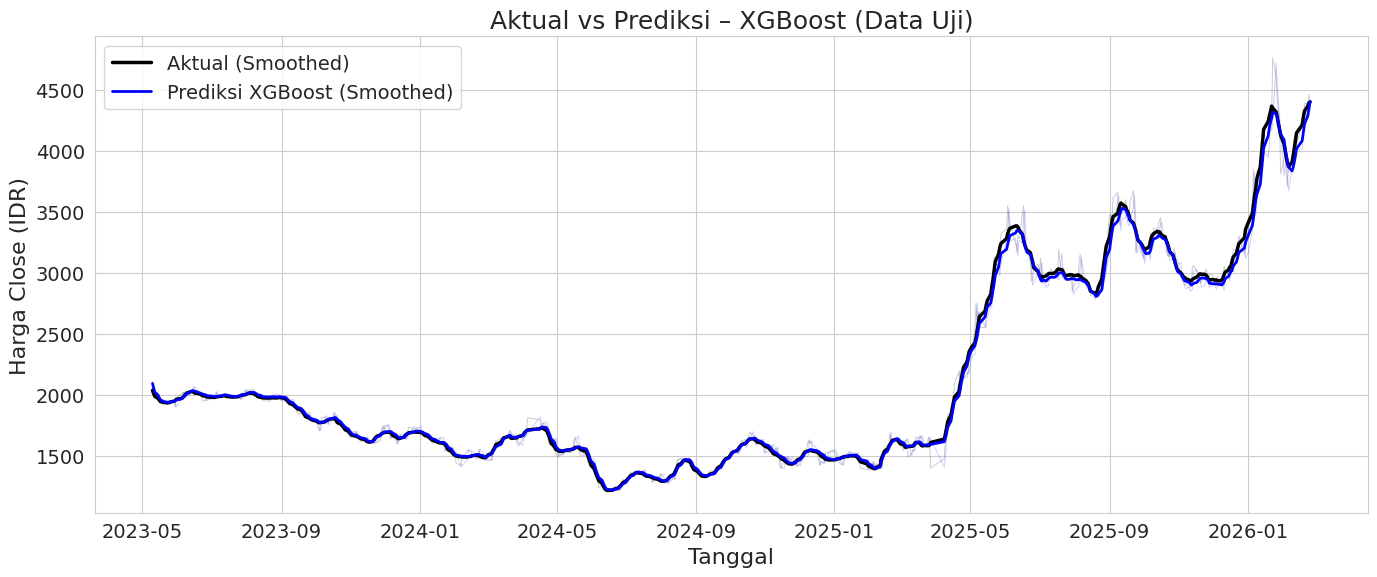

In [ ]:
plot_xgb = hasil_xgb.sort_index()
n_xgb = len(plot_xgb)
wl_xgb = 21 if n_xgb >= 21 else (n_xgb if n_xgb % 2 == 1 else n_xgb - 1)
akt_s_xgb  = savgol_filter(plot_xgb["Aktual"].values,   window_length=wl_xgb, polyorder=3)
pred_s_xgb = savgol_filter(plot_xgb["Prediksi"].values, window_length=wl_xgb, polyorder=3)

plt.figure(figsize=(14, 6))
plt.plot(plot_xgb.index, plot_xgb["Aktual"],   color="black", alpha=0.2, linewidth=0.7)
plt.plot(plot_xgb.index, plot_xgb["Prediksi"], color="blue",  alpha=0.2, linewidth=0.7)
plt.plot(plot_xgb.index, akt_s_xgb,  label="Aktual (Smoothed)",           color="black", linewidth=2.5)
plt.plot(plot_xgb.index, pred_s_xgb, label="Prediksi XGBoost (Smoothed)", color="blue",  linewidth=2)
plt.title("Aktual vs Prediksi – XGBoost (Data Uji)")
plt.xlabel("Tanggal"); plt.ylabel("Harga Close (IDR)")
plt.legend(); plt.tight_layout(); plt.show()

### 5.2 Actual vs Predicted: Random Forest

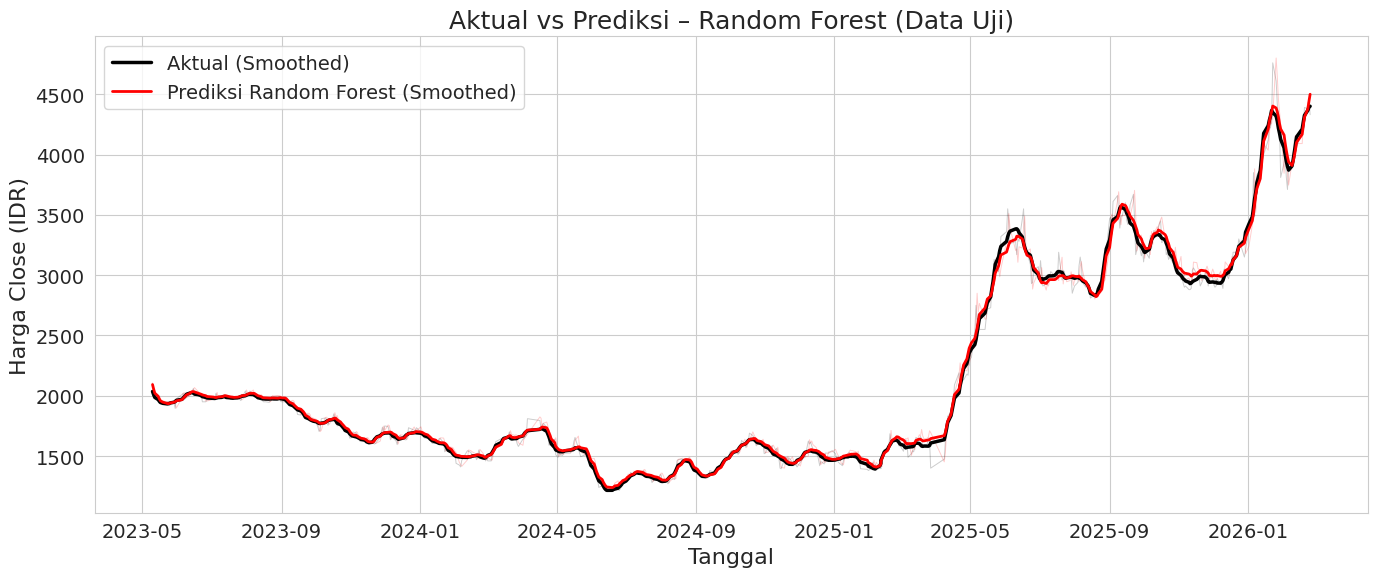

In [ ]:
plot_rf = hasil_rf.sort_index()
n_rf = len(plot_rf)
wl_rf = 21 if n_rf >= 21 else (n_rf if n_rf % 2 == 1 else n_rf - 1)
akt_s_rf  = savgol_filter(plot_rf["Aktual"].values,   window_length=wl_rf, polyorder=3)
pred_s_rf = savgol_filter(plot_rf["Prediksi"].values, window_length=wl_rf, polyorder=3)

plt.figure(figsize=(14, 6))
plt.plot(plot_rf.index, plot_rf["Aktual"],   color="black", alpha=0.2, linewidth=0.7)
plt.plot(plot_rf.index, plot_rf["Prediksi"], color="red",   alpha=0.2, linewidth=0.7)
plt.plot(plot_rf.index, akt_s_rf,  label="Aktual (Smoothed)",                 color="black", linewidth=2.5)
plt.plot(plot_rf.index, pred_s_rf, label="Prediksi Random Forest (Smoothed)", color="red",   linewidth=2)
plt.title("Aktual vs Prediksi – Random Forest (Data Uji)")
plt.xlabel("Tanggal"); plt.ylabel("Harga Close (IDR)")
plt.legend(); plt.tight_layout(); plt.show()

### 5.3 Actual vs Predicted: Both Models

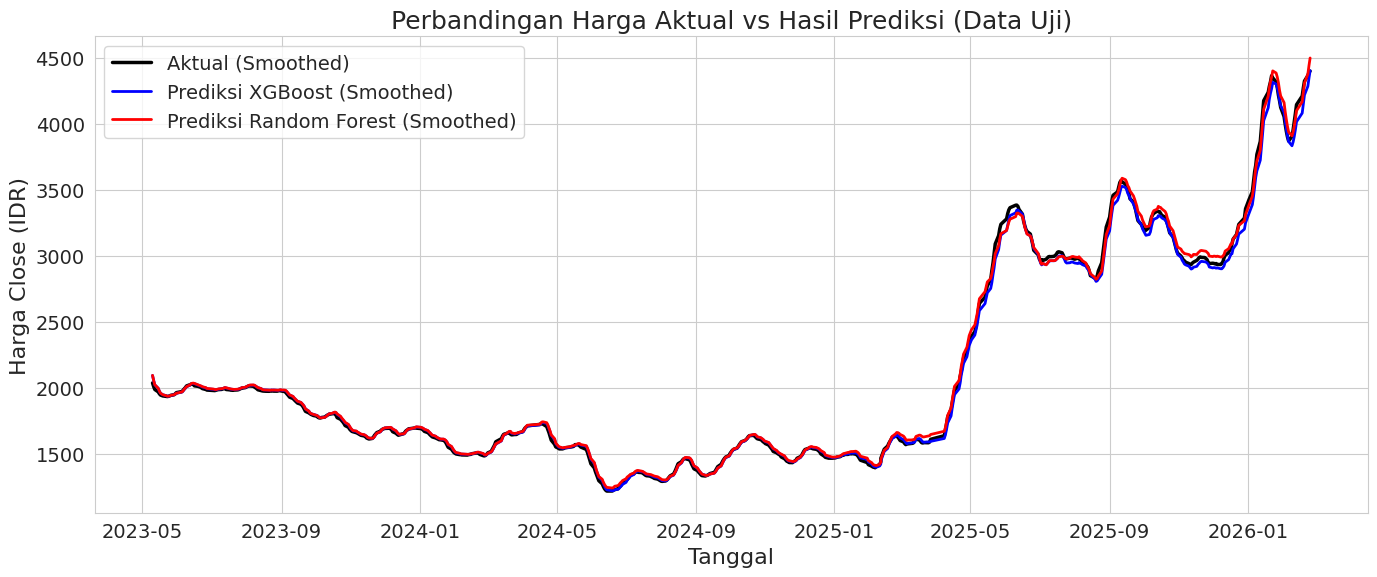

In [ ]:
plot_df = pd.DataFrame({
    "Aktual"       : hasil_xgb["Aktual"],
    "XGBoost"      : hasil_xgb["Prediksi"],
    "Random Forest": hasil_rf["Prediksi"]
}).sort_index()

n_df = len(plot_df)
wl_df = 21 if n_df >= 21 else (n_df if n_df % 2 == 1 else n_df - 1)
akt_s = savgol_filter(plot_df["Aktual"].values,        window_length=wl_df, polyorder=3)
xgb_s = savgol_filter(plot_df["XGBoost"].values,       window_length=wl_df, polyorder=3)
rf_s  = savgol_filter(plot_df["Random Forest"].values, window_length=wl_df, polyorder=3)

plt.figure(figsize=(14, 6))
plt.plot(plot_df.index, akt_s, label="Aktual (Smoothed)",                color="black", linewidth=2.5)
plt.plot(plot_df.index, xgb_s, label="Prediksi XGBoost (Smoothed)",       color="blue",  linewidth=2)
plt.plot(plot_df.index, rf_s,  label="Prediksi Random Forest (Smoothed)", color="red",   linewidth=2)
plt.title("Perbandingan Harga Aktual vs Hasil Prediksi (Data Uji)")
plt.xlabel("Tanggal"); plt.ylabel("Harga Close (IDR)")
plt.legend(); plt.tight_layout(); plt.show()

### 5.4 Actual vs Predicted Scatter Plot

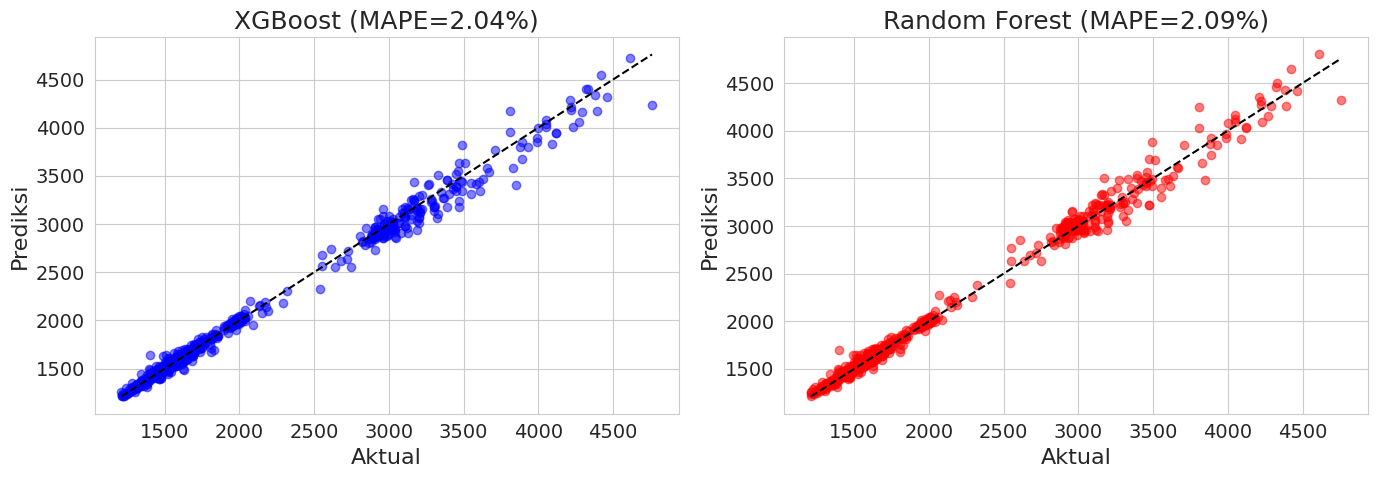

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(y_actual_xgb, y_pred_xgb, alpha=0.5, color="blue")
axes[0].plot([y_actual_xgb.min(), y_actual_xgb.max()], [y_actual_xgb.min(), y_actual_xgb.max()], "k--")
axes[0].set_title(f"XGBoost (MAPE={res_xgb['MAPE (%)']:.2f}%)")
axes[0].set_xlabel("Aktual"); axes[0].set_ylabel("Prediksi")

axes[1].scatter(y_actual_rf, y_pred_rf, alpha=0.5, color="red")
axes[1].plot([y_actual_rf.min(), y_actual_rf.max()], [y_actual_rf.min(), y_actual_rf.max()], "k--")
axes[1].set_title(f"Random Forest (MAPE={res_rf['MAPE (%)']:.2f}%)")
axes[1].set_xlabel("Aktual"); axes[1].set_ylabel("Prediksi")

plt.tight_layout(); plt.show()

### 5.5 Residual Distribution

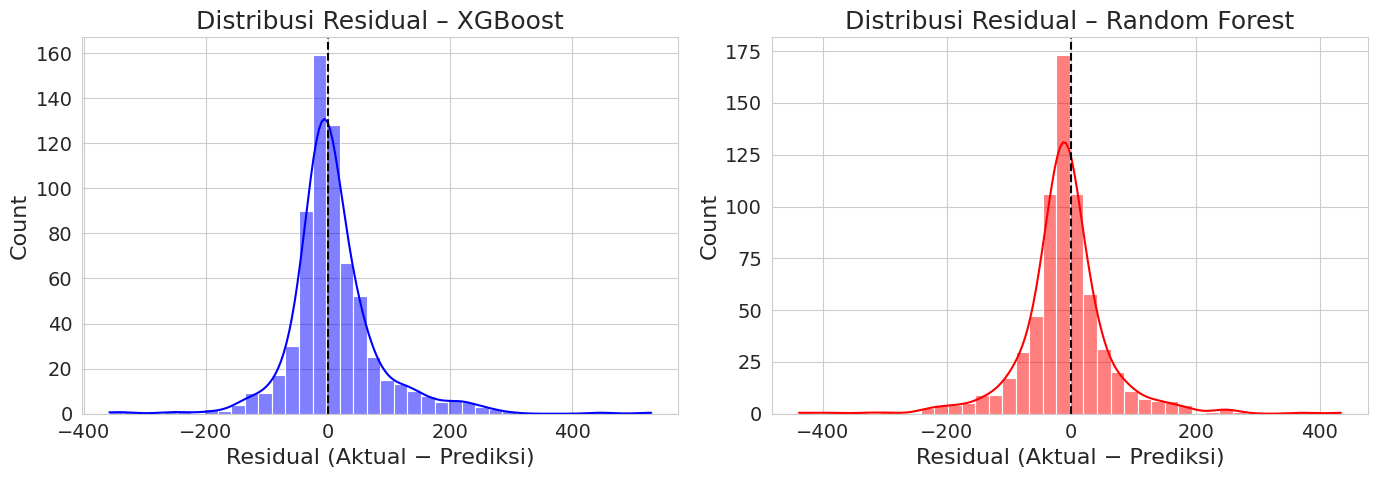

In [ ]:
residual_xgb = y_actual_xgb - y_pred_xgb
residual_rf  = y_actual_rf - y_pred_rf

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.histplot(residual_xgb, bins=40, kde=True, color="blue", ax=axes[0])
axes[0].axvline(0, color="black", linestyle="--")
axes[0].set_title("Distribusi Residual – XGBoost")
axes[0].set_xlabel("Residual (Aktual − Prediksi)")

sns.histplot(residual_rf, bins=40, kde=True, color="red", ax=axes[1])
axes[1].axvline(0, color="black", linestyle="--")
axes[1].set_title("Distribusi Residual – Random Forest")
axes[1].set_xlabel("Residual (Aktual − Prediksi)")

plt.tight_layout(); plt.show()

### 5.6 MAPE Comparison

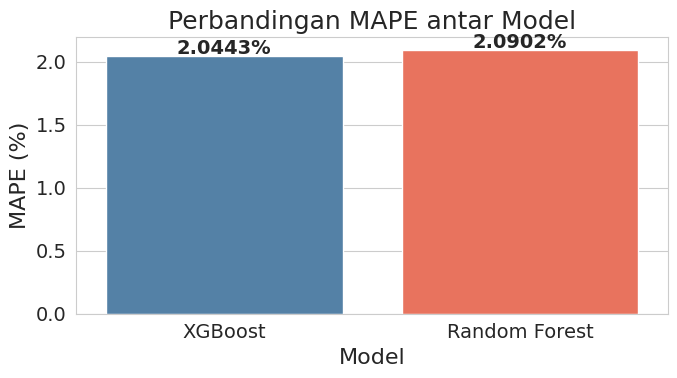

In [ ]:
plt.figure(figsize=(7, 4))
sns.barplot(x="Model", y="MAPE (%)", data=hasil, palette=["steelblue", "tomato"])
for i, v in enumerate(hasil["MAPE (%)"]):
    plt.text(i, v + 0.02, f"{v:.4f}%", ha="center", fontweight="bold")
plt.title("Perbandingan MAPE antar Model")
plt.tight_layout()
plt.show()

### 5.7 30-Day Forward Forecast

Drift harian rata-rata (60 hari terakhir):
  Gold_Close   : +0.3684% /hari  ->  hari-1: 5195.61   hari-30: 5781.44
  Nickel_Close : +0.3060% /hari  ->  hari-1: 1777.51   hari-30: 1942.44
  USDIDR_Close : +0.0118% /hari  ->  hari-1: 16751.78   hari-30: 16809.25


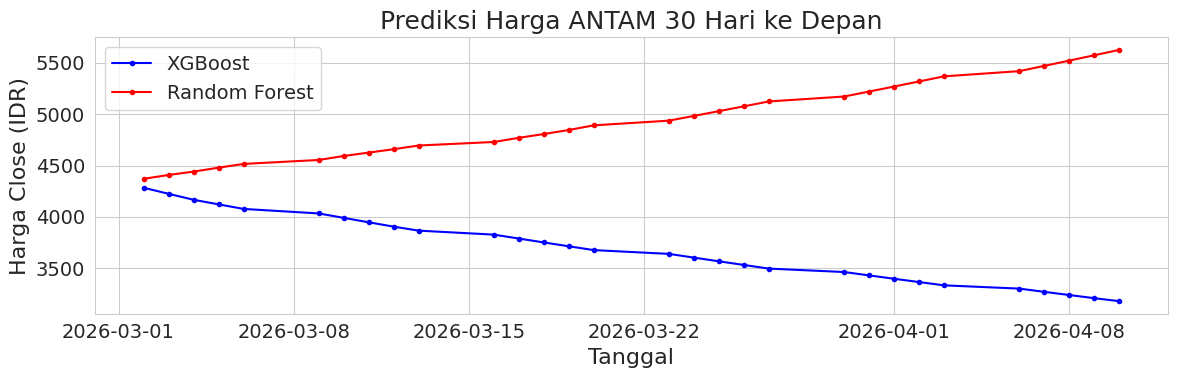

XGBoost       - Hari ke-1: 4283.38 | Hari ke-30: 3176.99
Random Forest - Hari ke-1: 4370.31  | Hari ke-30: 5627.73


In [ ]:
# Prediksi rekursif 30 hari ke depan dengan fitur yang IKUT DIPERBARUI
# setiap iterasi, bukan dibekukan pada nilai hari terakhir data historis.
#
# - Open/High/Low: mengikuti harga hasil prediksi hari sebelumnya (naive,
#   diasumsikan Open=High=Low=Close prediksi karena tidak ada model intraday).
# - SMA_50, SMA_200, RSI: DIHITUNG ULANG setiap hari dari riwayat Close
#   (data aktual + hasil prediksi sejauh ini), sehingga ikut bergerak
#   seiring waktu sebagaimana seharusnya.
# - Gold_Close, Nickel_Close, USDIDR_Close: variabel eksogen yang tidak
#   memiliki model prediksi tersendiri di penelitian ini. Alih-alih
#   dibekukan konstan (yang secara implisit mengasumsikan harga emas/
#   nikel/kurs sama sekali tidak berubah selama 30 hari -- asumsi yang
#   tidak realistis), nilainya diekstrapolasi memakai pendekatan
#   "naive drift": rata-rata log-return harian dari N hari terakhir data
#   historis dihitung, lalu diproyeksikan maju secara deterministik.
#   Pendekatan ini adalah baseline peramalan deret waktu yang umum dipakai
#   ketika tidak tersedia model peramalan khusus untuk variabel eksogen,
#   dan tetap mencerminkan tren arah pergerakan terakhir tanpa mengklaim
#   akurasi prediksi harga komoditas itu sendiri (bukan fokus penelitian
#   ini). Volume tetap memakai persistence karena tidak memiliki tren
#   terarah yang jelas untuk diekstrapolasi.

N_FORECAST = 30
DRIFT_WINDOW = 60  # jumlah hari terakhir yang dipakai untuk menghitung rata-rata drift

last_price = close_price.iloc[-1]

# riwayat Close: gabungan seluruh data historis (df_model, bukan hanya X)
# supaya SMA_200 punya cukup data untuk dihitung ulang tiap iterasi
close_history_base = df_model["Close"].copy()

last_volume = df_model["Volume"].iloc[-1]

def estimate_daily_drift(series, window=DRIFT_WINDOW):
    """Menghitung rata-rata log-return harian dari `window` hari terakhir,
    dipakai sebagai laju perubahan (drift) harian untuk ekstrapolasi naive
    ke depan. Mengembalikan 0.0 (persistence) bila data tidak mencukupi."""
    recent = series.iloc[-window:]
    if len(recent) < 10 or (recent <= 0).any():
        return 0.0
    log_returns = np.log(recent / recent.shift(1)).dropna()
    return log_returns.mean() if len(log_returns) > 0 else 0.0

def project_forward(last_value, drift, n_steps):
    """Memproyeksikan `n_steps` ke depan dari last_value dengan drift log
    harian yang konstan (naive random-walk-with-drift, deterministik)."""
    return [last_value * np.exp(drift * step) for step in range(1, n_steps + 1)]

gold_drift    = estimate_daily_drift(df_model["Gold_Close"])
nickel_drift  = estimate_daily_drift(df_model["Nickel_Close"])
usdidr_drift  = estimate_daily_drift(df_model["USDIDR_Close"])

gold_forecast    = project_forward(df_model["Gold_Close"].iloc[-1],    gold_drift,   N_FORECAST)
nickel_forecast  = project_forward(df_model["Nickel_Close"].iloc[-1],  nickel_drift, N_FORECAST)
usdidr_forecast  = project_forward(df_model["USDIDR_Close"].iloc[-1],  usdidr_drift, N_FORECAST)

print(f"Drift harian rata-rata ({DRIFT_WINDOW} hari terakhir):")
print(f"  Gold_Close   : {gold_drift*100:+.4f}% /hari  ->  hari-1: {gold_forecast[0]:.2f}   hari-30: {gold_forecast[-1]:.2f}")
print(f"  Nickel_Close : {nickel_drift*100:+.4f}% /hari  ->  hari-1: {nickel_forecast[0]:.2f}   hari-30: {nickel_forecast[-1]:.2f}")
print(f"  USDIDR_Close : {usdidr_drift*100:+.4f}% /hari  ->  hari-1: {usdidr_forecast[0]:.2f}   hari-30: {usdidr_forecast[-1]:.2f}")

def build_next_features(close_history, next_price, day_idx):
    """Menghitung ulang SMA_50, SMA_200, RSI dari riwayat Close terbaru
    (termasuk harga hasil prediksi), lalu menyusun satu baris fitur baru.
    Gold_Close/Nickel_Close/USDIDR_Close diambil dari hasil ekstrapolasi
    naive drift pada hari ke-`day_idx` (bukan nilai beku)."""
    sma_50  = close_history.rolling(window=50,  min_periods=20).mean().iloc[-1]
    sma_200 = close_history.rolling(window=200, min_periods=50).mean().iloc[-1]
    rsi_val = compute_rsi(close_history, period=14).iloc[-1]

    row = pd.DataFrame({
        "Open": [next_price], "High": [next_price], "Low": [next_price],
        "Volume": [last_volume],
        "SMA_50": [sma_50], "SMA_200": [sma_200], "RSI": [rsi_val],
        "Gold_Close": [gold_forecast[day_idx]],
        "Nickel_Close": [nickel_forecast[day_idx]],
        "USDIDR_Close": [usdidr_forecast[day_idx]],
    })[features]
    return row

# --- XGBoost ---
future_xgb = []
price_xgb = last_price
close_hist_xgb = close_history_base.copy()
for i in range(N_FORECAST):
    feat_xgb = build_next_features(close_hist_xgb, price_xgb, i)
    ret = xgb_model.predict(feat_xgb)[0]
    price_xgb = price_xgb * (1 + ret)
    future_xgb.append(price_xgb)
    close_hist_xgb = pd.concat([close_hist_xgb, pd.Series([price_xgb], index=[close_hist_xgb.index[-1] + pd.Timedelta(days=1)])])

# --- Random Forest ---
future_rf = []
price_rf = last_price
close_hist_rf = close_history_base.copy()
for i in range(N_FORECAST):
    feat_rf = build_next_features(close_hist_rf, price_rf, i)
    ret = rf_model.predict(feat_rf)[0]
    price_rf = price_rf * (1 + ret)
    future_rf.append(price_rf)
    close_hist_rf = pd.concat([close_hist_rf, pd.Series([price_rf], index=[close_hist_rf.index[-1] + pd.Timedelta(days=1)])])

future_dates = pd.date_range(start=df.index[-1] + pd.Timedelta(days=1), periods=N_FORECAST, freq="B")
future_df = pd.DataFrame({"XGBoost": future_xgb, "Random Forest": future_rf}, index=future_dates)

plt.figure(figsize=(12, 4))
plt.plot(future_df.index, future_df["XGBoost"],       color="blue", marker="o", markersize=3, label="XGBoost")
plt.plot(future_df.index, future_df["Random Forest"], color="red",  marker="o", markersize=3, label="Random Forest")
plt.title("Prediksi Harga ANTAM 30 Hari ke Depan")
plt.xlabel("Tanggal"); plt.ylabel("Harga Close (IDR)")
plt.legend(); plt.tight_layout(); plt.show()

print(f"XGBoost       - Hari ke-1: {future_xgb[0]:.2f} | Hari ke-30: {future_xgb[-1]:.2f}")
print(f"Random Forest - Hari ke-1: {future_rf[0]:.2f}  | Hari ke-30: {future_rf[-1]:.2f}")


### 5.8 Residual Descriptive Statistics

In [ ]:
error_xgb = y_actual_xgb - y_pred_xgb
error_rf = y_actual_rf - y_pred_rf

summary = pd.DataFrame({
    'XGBoost': [error_xgb.mean(), error_xgb.std(), error_xgb.min(), error_xgb.max()],
    'Random Forest': [error_rf.mean(), error_rf.std(), error_rf.min(), error_rf.max()]
}, index=['Rata-rata Error', 'Std Deviasi Error', 'Error Minimum', 'Error Maksimum'])

summary = summary.round(2)
print(summary)

                   XGBoost  Random Forest
Rata-rata Error       9.61         -11.08
Std Deviasi Error    74.95          73.17
Error Minimum      -358.13        -438.21
Error Maksimum      529.30         433.77
